# Tumour Volume Comparison: Simulation vs Romano et al. (2021)

Compares simulated tumour volume trajectories (with clonal heterogeneity) against
the experimental data from Romano et al. and Tanaya's baseline model.

**Approach:** Load all trials per scenario, average across trials, convert cell counts
to tumour volume (% of brain), and align the x-axis so that radiation at timestep 200
maps to Day 12 post-implantation (matching Romano et al.).

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "HALModeling2024Outs"

# --- Volume conversion constants ---
# Each grid cell represents a 100um x 100um x 100um voxel of tissue.
# This is a standard approximation for 2D ABMs — the grid is 2D but each
# site is treated as a 3D voxel with depth to enable volume estimation.
# Source: Tanaya's MSc report, page 30; Romano et al. (2021)
VOXEL_VOLUME_MM3 = 0.001       # 100um x 100um x 100um = 0.001 mm³ per cell
RAT_BRAIN_VOLUME_MM3 = 2000    # Fischer 344 rat brain volume in mm³
GRID_CELLS = 10000             # 100x100 grid = 10,000 total sites

# --- Timestep-to-day mapping ---
# Radiation is applied at timestep 200 in the simulation.
# Romano et al. (2021) applied radiation on Day 12 post-implantation.
# We align these so that timestep 200 = Day 12, and all other timesteps
# shift accordingly: day = 12 + (timestep - 200)
RADIATION_TIMESTEP = 200
RADIATION_DAY = 12

def timestep_to_day(timestep):
    """Convert simulation timestep to biological day post-implantation.
    Timestep 0 = Day -188 (tumour seeding), Timestep 200 = Day 12 (radiation)."""
    return RADIATION_DAY + (timestep - RADIATION_TIMESTEP)

def cell_count_to_volume_pct(count):
    """Convert cell count to tumour volume as % of rat brain.
    Formula: (count * 0.001 mm³) / 2000 mm³ * 100"""
    return (count * VOXEL_VOLUME_MM3 / RAT_BRAIN_VOLUME_MM3) * 100

print("Setup complete.")

Setup complete.


### Load all trials per scenario and compute mean + std

In [2]:
def load_all_trials(scenario, min_date="20260415"):
    """
    Load all CSV trials for a scenario, filtering out old runs.
    Only includes files with timestamp >= min_date to avoid mixing
    pre-bug-fix / pre-heterogeneity data.
    """
    # Build path to the scenario's output folder (e.g. HALModeling2024Outs/ScenarioMRT200/)
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")

    # Find all CSV files matching the trial naming pattern
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))

    if not csv_files:
        print(f"  WARNING: No CSVs found for {scenario}")
        return []

    # Filter by date embedded in filename: TrialRunCounts_YYYYMMDD_HHMMSS.csv
    # This ensures we only use data generated after the bug fixes and
    # heterogeneity features were added (April 15, 2026 onwards).
    filtered = []
    skipped = 0
    for f in csv_files:
        basename = os.path.basename(f)
        date_part = basename.split('_')[1]  # extract YYYYMMDD portion
        if date_part >= min_date:           # string comparison works because YYYYMMDD is lexicographic
            filtered.append(f)
        else:
            skipped += 1

    if skipped > 0:
        print(f"  {scenario}: skipped {skipped} old runs (before {min_date})")

    if not filtered:
        print(f"  WARNING: No CSVs for {scenario} after date filter")
        return []

    # Read each filtered CSV into a pandas DataFrame
    trials = [pd.read_csv(f) for f in filtered]
    print(f"  {scenario}: {len(trials)} trials, {len(trials[0])} timesteps each")
    return trials

def compute_mean_volume(trials):
    """
    Given a list of trial DataFrames, compute mean and std of tumour volume
    at each timestep. Returns (days, mean_vol, std_vol).
    """
    # Truncate all trials to the shortest length so arrays can be stacked
    min_len = min(len(df) for df in trials)

    # Extract TumorCells column from each trial and stack into a 2D numpy array
    # Shape: (n_trials, n_timesteps) — one row per trial
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])

    # Convert raw cell counts to tumour volume as % of rat brain
    # using the voxel-based formula defined in the setup cell
    all_volumes = cell_count_to_volume_pct(all_counts)

    # Compute mean and standard deviation across trials (axis=0 = across rows)
    mean_vol = np.mean(all_volumes, axis=0)
    std_vol = np.std(all_volumes, axis=0)

    # Convert simulation timesteps to biological days for the x-axis
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)

    return days, mean_vol, std_vol

# Scenarios matching Romano et al. (2021) treatment groups:
# Control = no radiation, BB = broad beam (uniform dose across whole tumour),
# MRT = microbeam radiation therapy (narrow beams, high peak dose),
# MB = minibeam (wider beams than MRT, lower peak dose).
# Numbers after the prefix are peak dose in Gy.
scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

print("Loading trials (filtering out pre-April 15 runs)...")
scenario_data = {}
for scen in scenarios:
    trials = load_all_trials(scen)
    if trials:
        # Compute the mean volume trajectory and store in a dict for later plotting
        days, mean_vol, std_vol = compute_mean_volume(trials)
        scenario_data[scen] = {
            'days': days,
            'mean': mean_vol,
            'std': std_vol,
            'n_trials': len(trials)
        }

print(f"\nLoaded {len(scenario_data)} scenarios.")

Loading trials (filtering out pre-April 15 runs)...
  Control: 11 trials, 541 timesteps each
  BB5: 10 trials, 541 timesteps each
  BB10: 10 trials, 541 timesteps each
  BB15: 10 trials, 541 timesteps each
  MRT200: 10 trials, 541 timesteps each
  MRT400: 10 trials, 541 timesteps each
  MRT600: 13 trials, 541 timesteps each
  MB180: 10 trials, 541 timesteps each
  MB350: 10 trials, 541 timesteps each

Loaded 9 scenarios.


### Main comparison plot

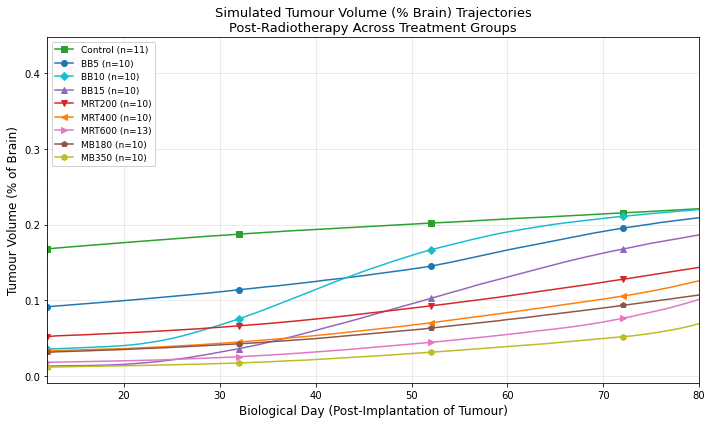

Saved to HALModeling2024Outs/tumour_volume_comparison.png


In [3]:
# --- Main comparison plot: tumour volume trajectories across all treatment groups ---
# Each scenario gets a unique colour and marker so they can be distinguished.
# Colours are chosen to loosely match Romano et al. figure conventions.
scenario_style = {
    'Control':  {'color': '#2ca02c', 'marker': 's', 'label': 'Control'},
    'BB5':      {'color': '#1f77b4', 'marker': 'o', 'label': 'BB5'},
    'BB10':     {'color': '#17becf', 'marker': 'D', 'label': 'BB10'},
    'BB15':     {'color': '#9467bd', 'marker': '^', 'label': 'BB15'},
    'MRT200':   {'color': '#d62728', 'marker': 'v', 'label': 'MRT200'},
    'MRT400':   {'color': '#ff7f0e', 'marker': '<', 'label': 'MRT400'},
    'MRT600':   {'color': '#e377c2', 'marker': '>', 'label': 'MRT600'},
    'MB180':    {'color': '#8c564b', 'marker': 'p', 'label': 'MB180'},
    'MB350':    {'color': '#bcbd22', 'marker': 'h', 'label': 'MB350'},
}

# Create a single-panel figure
fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]

    # Only plot from Day 12 onward (post-treatment) to match Romano et al.
    # Pre-treatment growth is identical across scenarios (no radiation yet)
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]

    # Subsample markers every 20 timesteps so the plot isn't cluttered
    marker_every = 20

    # Plot the mean tumour volume trajectory for this scenario
    ax.plot(days, mean,
            color=style['color'],
            marker=style['marker'],
            markevery=marker_every,
            markersize=6,
            linewidth=1.5,
            label=f"{style['label']} (n={d['n_trials']})")

# Add a vertical dashed line marking the day radiation was applied
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(RADIATION_DAY + 1, ax.get_ylim()[1] * 0.95, 'Treatment\n(Day 12)',
        fontsize=9, color='grey', va='top')

# Label axes and add legend
ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Tumour Volume (% of Brain)', fontsize=12)
ax.set_title('Simulated Tumour Volume (% Brain) Trajectories\n'
             'Post-Radiotherapy Across Treatment Groups', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 80)  # crop x-axis to the clinically relevant window

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_comparison.png")

### Per-scenario subplots — ABM vs In Vivo

Each panel shows one radiation scenario. Blue lines with error bars = ABM simulation
mean ± SD across 10 runs. Dashed grey lines with × markers = Romano et al. (2021)
in vivo experimental data (where available). Both normalised to [0, 1] for shape comparison.

Top row: MRT (Pred_MRT180, MRT200, Pred_MRT350, MRT400, MRT600)
Bottom row: MB (MB180, Pred_MB200, MB350, Pred_MB400, Pred_MB600)

  Pred_MRT180: 10 trials loaded
  MRT200: 10 trials loaded
  Pred_MRT350: 10 trials loaded
  MRT400: 10 trials loaded
  MRT600: 13 trials loaded
  MB180: 10 trials loaded
  Pred_MB200: 10 trials loaded
  MB350: 10 trials loaded
  Pred_MB400: 10 trials loaded
  Pred_MB600: 10 trials loaded


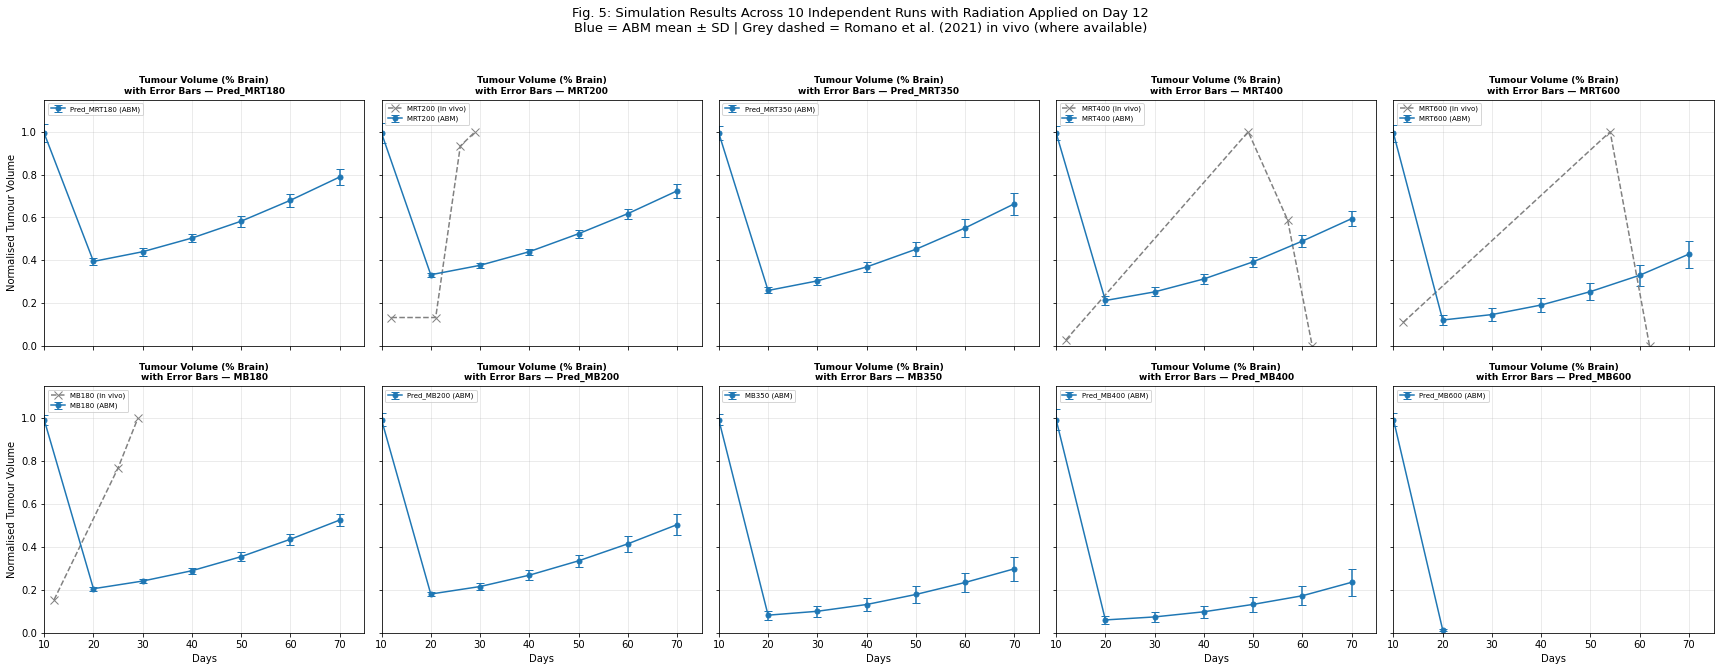

Saved to HALModeling2024Outs/per_scenario_runs_vs_invivo.png


In [4]:
# --- Romano et al. (2021) in vivo data (extracted from figures by Tanaya) ---
# These data points were manually read off the published tumour volume curves.
# Format: (day_post_implantation, tumour_volume_percent_of_brain)
# Only scenarios that Romano tested in vivo are included here.
in_vivo_data = {
    "MRT200":  [(12, 2), (21, 2), (26, 14), (29, 15)],
    "MRT400":  [(12, 2), (49, 68), (57, 40), (62, 0)],
    "MRT600":  [(12, 2), (54, 18), (62, 0)],
    "MB180":   [(12, 2), (25, 10), (29, 13)],
}

def load_individual_volumes(scenario, min_date="20260415"):
    """Load each trial's tumour volume time series individually
    (not averaged) so we can compute per-scenario error bars."""
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    # Apply the same date filter as load_all_trials
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not filtered:
        return None, None
    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    # Build a 2D array: shape (n_trials, n_timesteps), each row = one trial's volume
    all_volumes = np.array([
        cell_count_to_volume_pct(df['TumorCells'].values[:min_len])
        for df in trials
    ])
    return days, all_volumes

# --- Scenario layout: top row = MRT variants, bottom row = MB variants ---
# "Pred_" prefix = prediction scenarios at doses Romano did not test in vivo.
# These are novel predictions generated by the ABM to guide future experiments.
scenario_map = {
    "Pred_MRT180": "Pred_MRT180",
    "MRT200":      "MRT200",
    "Pred_MRT350": "Pred_MRT350",
    "MRT400":      "MRT400",
    "MRT600":      "MRT600",
    "MB180":       "MB180",
    "Pred_MB200":  "Pred_MB200",
    "MB350":       "MB350",
    "Pred_MB400":  "Pred_MB400",
    "Pred_MB600":  "Pred_MB600",
}

# Define the 2x5 grid layout: MRT on top, MB on bottom
plot_order = [
    ["Pred_MRT180", "MRT200", "Pred_MRT350", "MRT400", "MRT600"],
    ["MB180", "Pred_MB200", "MB350", "Pred_MB400", "Pred_MB600"],
]

# Pre-load ABM data for all scenarios into a dict
indiv_data = {}
for label, folder_name in scenario_map.items():
    days, vols = load_individual_volumes(folder_name)
    if days is not None:
        indiv_data[label] = {'days': days, 'volumes': vols}
        print(f"  {label}: {vols.shape[0]} trials loaded")
    else:
        print(f"  WARNING: No data for {label}")

# --- Create 2x5 subplot grid with shared axes for easy cross-panel comparison ---
fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharey=True, sharex=True)

DAY_MIN = 10   # start just before radiation day
DAY_MAX = 75   # end of clinically relevant window

for row_idx, row_scenarios in enumerate(plot_order):
    for col_idx, scen in enumerate(row_scenarios):
        ax = axes[row_idx, col_idx]

        if scen not in indiv_data:
            ax.set_title(f'{scen}\n(no data)', fontsize=10)
            ax.set_visible(True)
            continue

        d = indiv_data[scen]

        # Filter to the post-treatment day range
        mask = (d['days'] >= DAY_MIN) & (d['days'] <= DAY_MAX)
        days_abm = d['days'][mask]
        vols_abm = d['volumes'][:, mask]  # slice all trials to this day range

        # Compute mean and standard deviation across all trials
        abm_mean = vols_abm.mean(axis=0)
        abm_std  = vols_abm.std(axis=0)

        # Normalise ABM volumes to [0, 1] range so ABM and in vivo curves
        # can be visually compared despite having different absolute scales.
        # Without this, ABM volumes (tiny %) would be invisible next to in vivo.
        abm_max = abm_mean.max()
        if abm_max > 0:
            abm_mean_norm = abm_mean / abm_max
            abm_std_norm  = abm_std / abm_max
        else:
            abm_mean_norm = abm_mean
            abm_std_norm  = abm_std

        # Plot ABM mean with error bars; subsample every 10 points to reduce clutter
        every = 10
        ax.errorbar(days_abm[::every], abm_mean_norm[::every],
                    yerr=abm_std_norm[::every],
                    fmt='o-', color='#1f77b4', capsize=4, markersize=5,
                    linewidth=1.5, label=f'{scen} (ABM)')

        # Overlay in vivo data where Romano tested this exact dose
        if scen in in_vivo_data:
            iv_days, iv_vols = zip(*in_vivo_data[scen])  # unpack (day, vol) tuples
            iv_days = np.array(iv_days, dtype=float)
            iv_vols = np.array(iv_vols, dtype=float)
            # Normalise in vivo data to its own max for shape comparison
            iv_max = iv_vols.max()
            if iv_max > 0:
                iv_vols_norm = iv_vols / iv_max
            else:
                iv_vols_norm = iv_vols
            ax.plot(iv_days, iv_vols_norm, 'x--', color='grey', markersize=8,
                    linewidth=1.5, label=f'{scen} (in vivo)')

        ax.set_title(f'Tumour Volume (% Brain)\nwith Error Bars \u2014 {scen}',
                     fontsize=9, fontweight='bold')
        ax.set_xlim(DAY_MIN, DAY_MAX)
        ax.set_ylim(0, 1.15)
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

        # Only label outer edges to reduce clutter
        if col_idx == 0:
            ax.set_ylabel('Normalised Tumour Volume', fontsize=10)
        if row_idx == 1:
            ax.set_xlabel('Days', fontsize=10)

fig.suptitle(
    'Fig. 5: Simulation Results Across 10 Independent Runs with Radiation Applied on Day 12\n'
    'Blue = ABM mean \u00b1 SD | Grey dashed = Romano et al. (2021) in vivo (where available)',
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/per_scenario_runs_vs_invivo.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/per_scenario_runs_vs_invivo.png")

### Normalised slope comparison — In Vivo vs ABM (Fig. 4)

Each bar represents the tumour growth rate (slope of volume vs time) scaled relative
to the maximum within its dataset (in vivo or ABM). This normalisation enables a
relative comparison of treatment response dynamics between experimental and
simulated systems.

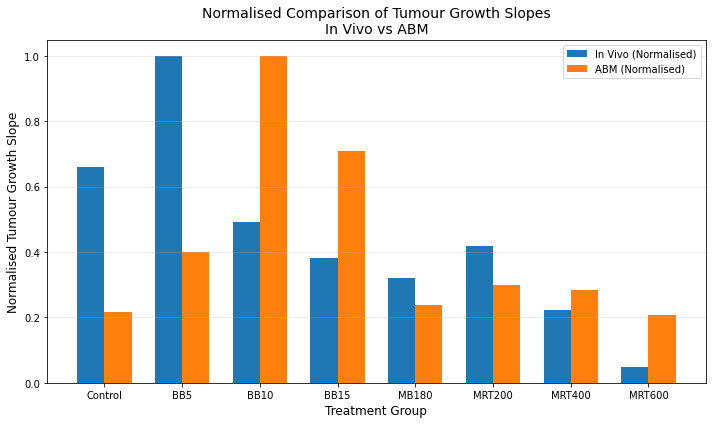


Treatment      In Vivo slope       ABM slope    IV norm   ABM norm
-----------------------------------------------------------------
Control               1.3214        0.000809      0.661      0.218
BB5                   2.0000        0.001482      1.000      0.399
BB10                  0.9826        0.003714      0.491      1.000
BB15                  0.7667        0.002631      0.383      0.708
MB180                 0.6392        0.000887      0.320      0.239
MRT200                0.8373        0.001114      0.419      0.300
MRT400                0.4460        0.001060      0.223      0.285
MRT600                0.0989        0.000766      0.049      0.206


In [5]:
from scipy.stats import linregress

# --- In vivo data points extracted from Romano et al. (2021) figures ---
# Format: (day_post_implantation, tumour_volume_%_of_brain)
# These were manually digitised from the published survival/volume curves.
in_vivo_slopes_data = {
    "Control": [(12, 2), (20, 12), (24, 18)],
    "BB5":     [(12, 2), (21, 20)],
    "BB10":    [(12, 2), (28, 15), (38, 28)],
    "BB15":    [(12, 2), (42, 25)],
    "MB180":   [(12, 2), (25, 10), (29, 13)],
    "MRT200":  [(12, 2), (21, 2), (26, 14), (29, 15)],
    "MRT400":  [(12, 2), (49, 68), (57, 40), (62, 0)],
    "MRT600":  [(12, 2), (54, 18), (62, 0)],
}

# Compute in vivo growth slopes using linear regression on the digitised points.
# linregress returns (slope, intercept, r, p, stderr) — we only need the slope.
# Slope = volume % gained per day, i.e. how fast the tumour grows post-treatment.
in_vivo_slopes = {}
for treatment, points in in_vivo_slopes_data.items():
    x, y = zip(*points)                     # separate days and volumes
    slope, _, _, _, _ = linregress(x, y)     # fit a straight line
    in_vivo_slopes[treatment] = slope

# --- ABM slopes: fit linear regression over the Day 12-60 window ---
# Using the same post-radiation time window for both in vivo and ABM
# ensures a fair comparison (same observation period).
slope_scenarios = ["Control", "BB5", "BB10", "BB15", "MB180", "MRT200", "MRT400", "MRT600"]

abm_slopes = {}
for scen in slope_scenarios:
    if scen in scenario_data:
        d = scenario_data[scen]
        # Boolean mask to select only data points between Day 12 and Day 60
        mask = (d['days'] >= 12) & (d['days'] <= 60)
        x = d['days'][mask].astype(float)  # linregress needs float, not int
        y = d['mean'][mask]                # mean tumour volume across 10 trials
        slope, _, _, _, _ = linregress(x, y)
        abm_slopes[scen] = slope

# --- Normalise both datasets to [0, 1] for visual comparison ---
# Raw slopes have very different scales: in vivo measures real tissue volume,
# ABM measures cell counts converted to tiny % values. Normalising each
# dataset to its own maximum lets us compare the RELATIVE RANKING of
# treatments (e.g. "does MRT600 grow slowest in both?").
iv_max = max(in_vivo_slopes.values())    # largest in vivo slope (for normalisation)
abm_max = max(abm_slopes.values())       # largest ABM slope

iv_norm  = {k: v / iv_max for k, v in in_vivo_slopes.items()}
abm_norm = {k: v / abm_max for k, v in abm_slopes.items()}

# --- Bar chart: side-by-side normalised slopes ---
treatments = list(in_vivo_slopes.keys())
x = np.arange(len(treatments))    # x positions for each treatment group
bar_width = 0.35                   # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Blue bars = in vivo, orange bars = ABM, placed side by side
bars_iv  = ax.bar(x - bar_width/2, [iv_norm[t] for t in treatments],
                  bar_width, label='In Vivo (Normalised)', color='#1f77b4')
bars_abm = ax.bar(x + bar_width/2, [abm_norm.get(t, 0) for t in treatments],
                  bar_width, label='ABM (Normalised)', color='#ff7f0e')

ax.set_xlabel('Treatment Group', fontsize=12)
ax.set_ylabel('Normalised Tumour Growth Slope', fontsize=12)
ax.set_title('Normalised Comparison of Tumour Growth Slopes\nIn Vivo vs ABM', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(treatments, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/slope_comparison_invivo_vs_abm.png', dpi=200, bbox_inches='tight')
plt.show()

# Print raw and normalised slopes as a reference table
print(f"\n{'Treatment':<12} {'In Vivo slope':>15} {'ABM slope':>15} {'IV norm':>10} {'ABM norm':>10}")
print("-" * 65)
for t in treatments:
    print(f"{t:<12} {in_vivo_slopes[t]:>15.4f} {abm_slopes.get(t, 0):>15.6f} {iv_norm[t]:>10.3f} {abm_norm.get(t, 0):>10.3f}")

### Summary table: final tumour volume per scenario

In [6]:
# --- Summary table: volume at key clinical timepoints ---
# Day 42 ~ 1 month post-treatment, Day 72 ~ 2 months post-treatment.
# These correspond to common clinical follow-up intervals.
# "Final Vol" and "Final Day" show where each scenario's simulation ended.
print(f"{'Scenario':<12} {'Trials':>6} {'Vol at Day 42':>15} {'Vol at Day 72':>15} {'Final Vol':>15} {'Final Day':>10}")
print("-" * 75)

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]

    # np.argmin finds the index where |days - target| is smallest,
    # effectively snapping to the closest available timestep
    day42_idx = np.argmin(np.abs(d['days'] - 42))
    day72_idx = np.argmin(np.abs(d['days'] - 72))

    # Format volumes as percentages with 4 decimal places
    vol42 = f"{d['mean'][day42_idx]:.4f}%"
    vol72 = f"{d['mean'][day72_idx]:.4f}%"
    vol_final = f"{d['mean'][-1]:.4f}%"    # last timestep
    final_day = f"{d['days'][-1]}"

    print(f"{scen:<12} {d['n_trials']:>6} {vol42:>15} {vol72:>15} {vol_final:>15} {final_day:>10}")

Scenario     Trials   Vol at Day 42   Vol at Day 72       Final Vol  Final Day
---------------------------------------------------------------------------
Control          11         0.1950%         0.2155%         0.4248%        352
BB5              10         0.1281%         0.1954%         0.4222%        352
BB10             10         0.1245%         0.2109%         0.4265%        352
BB15             10         0.0673%         0.1677%         0.4205%        352
MRT200           10         0.0780%         0.1278%         0.4138%        352
MRT400           10         0.0562%         0.1058%         0.4161%        352
MRT600           13         0.0337%         0.0764%         0.4159%        352
MB180            10         0.0518%         0.0934%         0.4181%        352
MB350            10         0.0233%         0.0521%         0.4222%        352


### Relative growth: normalised to volume at treatment day

This shows how much the tumour grew or shrank *relative to the treatment day*, 
making it easier to compare treatment effectiveness across scenarios regardless 
of the absolute volume scale.

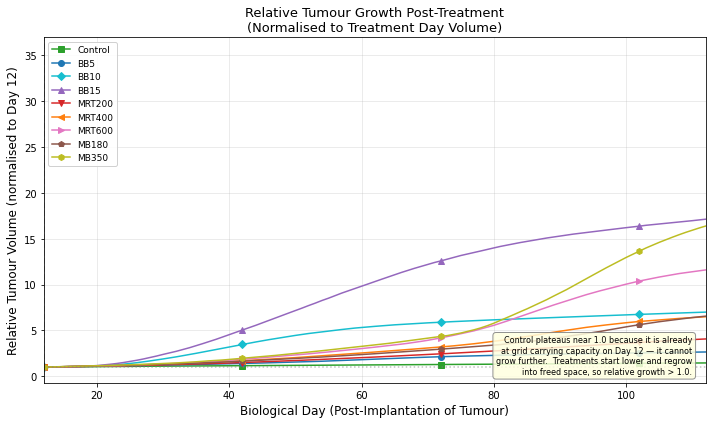

Saved to HALModeling2024Outs/tumour_volume_relative.png


In [7]:
# --- Relative growth: normalise each scenario's volume to its Day 12 value ---
# This shows how quickly the tumour regrows after treatment, independent of
# absolute volume.  A value of 1.0 means "same size as on treatment day".
#
# IMPORTANT — carrying capacity artefact:
# Control is near grid carrying capacity (~10,000 cells on 100x100 grid)
# at Day 12, so it physically cannot grow much further — its relative growth
# plateaus near 1.0.  Treated tumours start smaller post-radiation and regrow
# into freed space, so their relative growth exceeds 1.0 even though their
# absolute volume remains lower.  This is a grid saturation artefact, NOT
# evidence that treatment is worse than no treatment.

fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]

    # Filter to post-treatment days only
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]

    # Divide every volume by the volume on treatment day (Day 12).
    # This makes all scenarios start at 1.0, so we compare regrowth rates.
    vol_at_treatment = mean[0] if mean[0] > 0 else 1e-9  # avoid divide-by-zero
    normalised = mean / vol_at_treatment

    ax.plot(days, normalised,
            color=style['color'],
            marker=style['marker'],
            markevery=30,       # show a marker every 30 timesteps
            markersize=6,
            linewidth=1.5,
            label=style['label'])

# Horizontal line at y=1.0 = "same volume as treatment day" reference
ax.axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)
# Vertical line marking radiation day
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5)

# On-plot annotation explaining why Control appears flat
ax.annotate(
    'Control plateaus near 1.0 because it is already\n'
    'at grid carrying capacity on Day 12 \u2014 it cannot\n'
    'grow further.  Treatments start lower and regrow\n'
    'into freed space, so relative growth > 1.0.',
    xy=(0.98, 0.02), xycoords='axes fraction',
    fontsize=8, ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='grey', alpha=0.85))

ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Relative Tumour Volume (normalised to Day 12)', fontsize=12)
ax.set_title('Relative Tumour Growth Post-Treatment\n(Normalised to Treatment Day Volume)', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 112)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_relative.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_relative.png")

---

## Clone Growth — No Treatment (Control Scenario)

Three clones are seeded at the start of every simulation:

| Clone | Name | Initial fraction | Growth multiplier | Radiosensitivity | Immune-kill |
|-------|------|-----------------|------------------|-----------------|-------------|
| 0 | Baseline | 60 % | x1.0 | x1.0 | x1.0 |
| 1 | Proliferative | 25 % | x1.1 | x1.1 | x1.1 |
| 2 | Invasive / Resistant | 15 % | x0.95 | x0.4 | x0.3 |

This section uses the **Control** scenario CSVs (no radiation, immune suppression = 0.51) to show how each clone grows on its own.

In [8]:
# --- Clone growth setup (reuses BASE_DIR from the setup cell) ---
# This section focuses on the Control (no radiation) scenario to show
# how the three subclones grow without any treatment intervention.
SCENARIO  = "Control"
FOLDER    = os.path.join(BASE_DIR, f"Scenario{SCENARIO}")

# Column names in the CSV corresponding to each subclone's cell count.
# The ABM seeds 3 subclones at initialisation with different biological properties:
#   Clone 0 = Baseline       — standard GBM parameters (growth 1.0x, alpha 1.0x)
#   Clone 1 = Proliferative  — faster growth (1.1x), slightly more radiosensitive (alpha 1.1x)
#   Clone 2 = Invasive/Resistant — slower growth (0.95x), very radioresistant (alpha 0.4x)
CLONE_COLS   = ["TumorClone0", "TumorClone1", "TumorClone2"]
CLONE_LABELS = ["Clone 0 \u2013 Baseline", "Clone 1 \u2013 Proliferative", "Clone 2 \u2013 Invasive/Resistant"]
CLONE_COLORS = ["#d62728", "#ff7f0e", "#8c564b"]   # red, orange, brown

# Load all Control trial CSVs from the output folder
csv_files = sorted(glob.glob(os.path.join(FOLDER, "TrialRunCounts_*.csv")))
print(f"Found {len(csv_files)} Control run(s)")

# Read each CSV into a DataFrame
runs = [pd.read_csv(f) for f in csv_files]
# Confirm clone columns are present (they won't be in Tanaya's old data)
print(f"Columns available: {[c for c in runs[0].columns if 'Clone' in c]}")

Found 11 Control run(s)
Columns available: ['TumorClone0', 'TumorClone1', 'TumorClone2', 'TumorClone0Rad', 'TumorClone1Rad', 'TumorClone2Rad', 'Clone0DieProbRad', 'Clone0DieProbImm', 'Clone0DivProb', 'Clone1DieProbRad', 'Clone1DieProbImm', 'Clone1DivProb', 'Clone2DieProbRad', 'Clone2DieProbImm', 'Clone2DivProb']


### Individual clone growth — separate plots

Each panel shows one clone across all runs (thin lines) plus the mean (thick line).

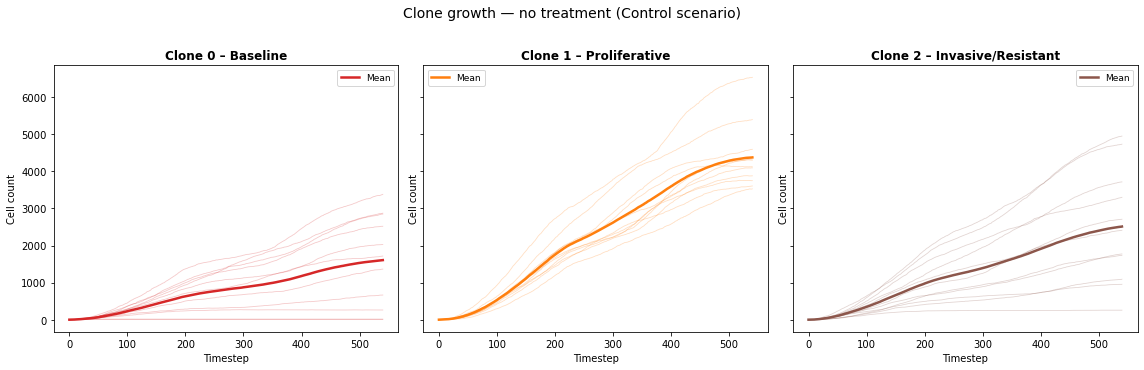

In [9]:
# --- Individual clone growth: one subplot per clone ---
# Each panel shows all 10 trial trajectories (faint lines) with the
# mean overlaid (bold line).  sharey=True ensures the y-axis scale
# is the same across all three panels for fair visual comparison.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, col, label, color in zip(axes, CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    # Plot each individual trial as a faint line to show inter-trial variability
    all_series = []
    for df in runs:
        t = df["Timestep"]
        y = df[col]
        ax.plot(t, y, color=color, alpha=0.25, linewidth=0.8)  # faint = individual run
        all_series.append(y.values)

    # Compute and overlay the mean across all trials as a bold line
    mean_y = np.mean(all_series, axis=0)
    ax.plot(runs[0]["Timestep"], mean_y, color=color, linewidth=2.5, label="Mean")

    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Cell count")
    ax.legend(fontsize=9)

fig.suptitle("Clone growth \u2014 no treatment (Control scenario)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### All three clones on one plot (mean +/- std)

Easier to compare relative growth rates side-by-side.

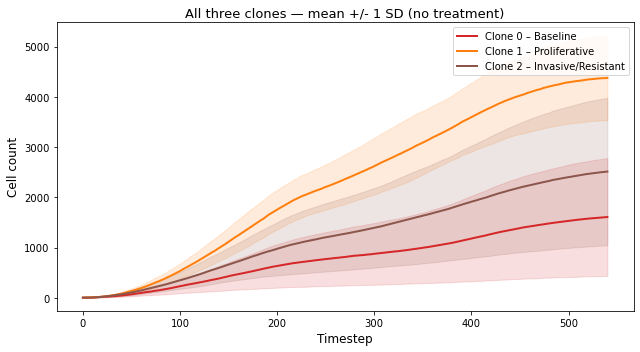

In [10]:
# --- All three clones overlaid on a single plot (mean +/- 1 SD) ---
# The shaded bands (fill_between) show 1 standard deviation across 10 trials.
# This reveals competitive dynamics: Clone 1 (Proliferative) tends to
# dominate over time due to its 1.1x growth rate multiplier, while
# Clone 2 (Resistant) grows slowest because of its 0.95x multiplier.
fig, ax = plt.subplots(figsize=(9, 5))

t = runs[0]["Timestep"].values  # x-axis: simulation timesteps

for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
    # Stack all trials into a 2D array for vectorised mean/std
    matrix = np.stack([df[col].values for df in runs])  # shape (n_runs, n_timesteps)
    mean   = matrix.mean(axis=0)  # mean count at each timestep
    std    = matrix.std(axis=0)   # spread across trials

    ax.plot(t, mean, color=color, linewidth=2, label=label)
    # Shaded band = mean +/- 1 SD to show trial-to-trial variability
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Cell count", fontsize=12)
ax.set_title("All three clones \u2014 mean +/- 1 SD (no treatment)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## Before vs After Bug Fixes — Tumour Volume Comparison

Side-by-side comparison of tumour volume trajectories from the **old buggy code**
(Tanaya's original, March 2026) and the **current fixed code** (with all bug fixes,
clonal heterogeneity, valley dose, etc.).

Key bugs fixed: lymphocyte migration gating, double random roll, clone count
tracking, radiation unapply, threshold percentage, radiobiology parameters,
static field persistence in BatchRunner, and more.

In [11]:
# --- Load OLD (buggy) simulation data from Tanaya's original code ---
# This directory contains output from Tanaya's unmodified ABM code
# (before any bug fixes or heterogeneity features were added).
# Used for before/after comparison to demonstrate the impact of fixes.
OLD_BASE_DIR = "/Users/nafisamaliat/Library/CloudStorage/OneDrive-UniversityofRoehampton/ROE/Year 3/Final Year Project/ABM_GliobMul/HALModeling2024Outs"

def load_old_trials(scenario):
    """Load all CSV trials from the old buggy code output.
    No date filter needed — all data in this folder is from the original code."""
    folder = os.path.join(OLD_BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    if not csv_files:
        return None
    # Read each CSV into a DataFrame
    trials = [pd.read_csv(f) for f in csv_files]
    min_len = min(len(df) for df in trials)
    # Extract TumorCells counts and convert to volume %
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])
    all_volumes = cell_count_to_volume_pct(all_counts)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    return {
        'days': days,
        'mean': all_volumes.mean(axis=0),
        'std': all_volumes.std(axis=0),
        'n_trials': len(trials),
        'trials': trials,       # keep raw DataFrames for clone-level before/after plots
        'min_len': min_len,
    }

# Load old data for all 9 scenarios
compare_scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]
old_data = {}
for scen in compare_scenarios:
    result = load_old_trials(scen)
    if result is not None:
        old_data[scen] = result
        print(f"  OLD {scen}: {result['n_trials']} trials")
    else:
        print(f"  OLD {scen}: no data")

print(f"\nLoaded old data for {len(old_data)} scenarios.")

  OLD Control: 8 trials
  OLD BB5: 4 trials
  OLD BB10: 39 trials
  OLD BB15: 12 trials
  OLD MRT200: 13 trials
  OLD MRT400: 18 trials
  OLD MRT600: 15 trials
  OLD MB180: 2 trials
  OLD MB350: 4 trials

Loaded old data for 9 scenarios.


### Before vs After — Tumour Volume Trajectories

Left panel: old buggy code (March 2026). Right panel: current fixed code (April 2026).
Same scenarios, same axes for direct comparison.

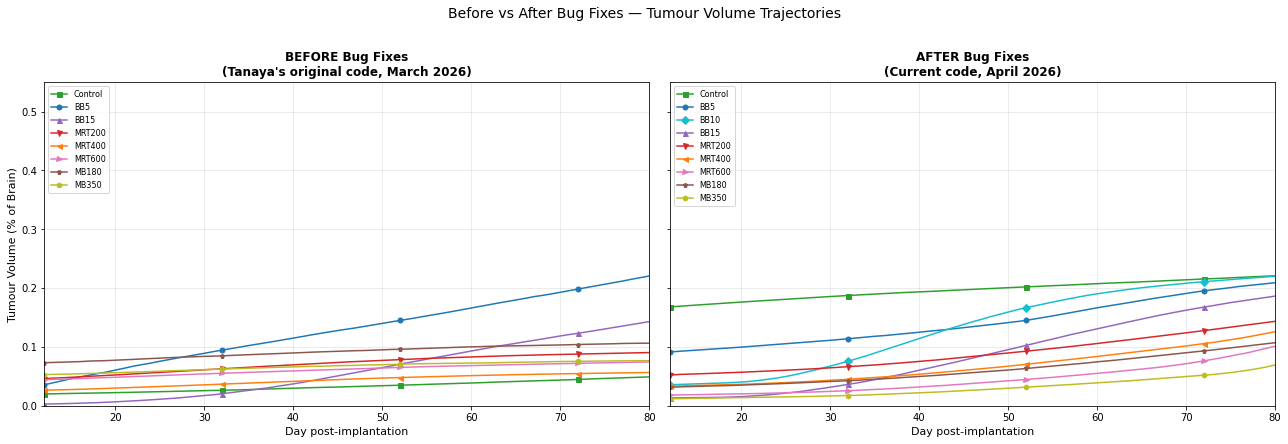

Saved to HALModeling2024Outs/before_after_volume.png


In [12]:
# --- Side-by-side: old (buggy) vs new (fixed) tumour volume trajectories ---
# Left panel = Tanaya's original code (before bug fixes)
# Right panel = current model (after all fixes + heterogeneity)
# Both panels share a y-axis so the volume scale is directly comparable.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

all_max = 0  # track the maximum volume across BOTH panels for y-axis scaling

# --- Left panel: OLD (buggy) code ---
for scen in compare_scenarios:
    if scen not in old_data:
        continue
    d = old_data[scen]
    style = scenario_style.get(scen, {'color': 'black', 'marker': 'o', 'label': scen})
    # Only show post-radiation period
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    if len(mean) == 0:
        continue
    all_max = max(all_max, mean.max())  # update global max
    ax1.plot(days, mean, color=style['color'], marker=style['marker'],
             markevery=20, markersize=5, linewidth=1.5, label=style['label'])

ax1.set_title('BEFORE Bug Fixes\n(Tanaya\'s original code, March 2026)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Day post-implantation', fontsize=11)
ax1.set_ylabel('Tumour Volume (% of Brain)', fontsize=11)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(RADIATION_DAY, 80)

# --- Right panel: NEW (fixed) code ---
for scen in compare_scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style.get(scen, {'color': 'black', 'marker': 'o', 'label': scen})
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    if len(mean) == 0:
        continue
    all_max = max(all_max, mean.max())
    ax2.plot(days, mean, color=style['color'], marker=style['marker'],
             markevery=20, markersize=5, linewidth=1.5, label=style['label'])

ax2.set_title('AFTER Bug Fixes\n(Current code, April 2026)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day post-implantation', fontsize=11)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(RADIATION_DAY, 80)

# Force both panels to the same y-axis range using the global maximum
if all_max > 0:
    ax1.set_ylim(0, all_max * 1.1)

fig.suptitle('Before vs After Bug Fixes \u2014 Tumour Volume Trajectories', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/before_after_volume.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/before_after_volume.png")

### Before vs After — Clone Dynamics per Scenario

Each row compares one scenario. Left = old code (single run, buggy clone tracking).
Right = new code (single run from latest batch, correct clone tracking).
Shows how clone populations behave differently after fixing clone count tracking,
seeding, and radiation mechanics.

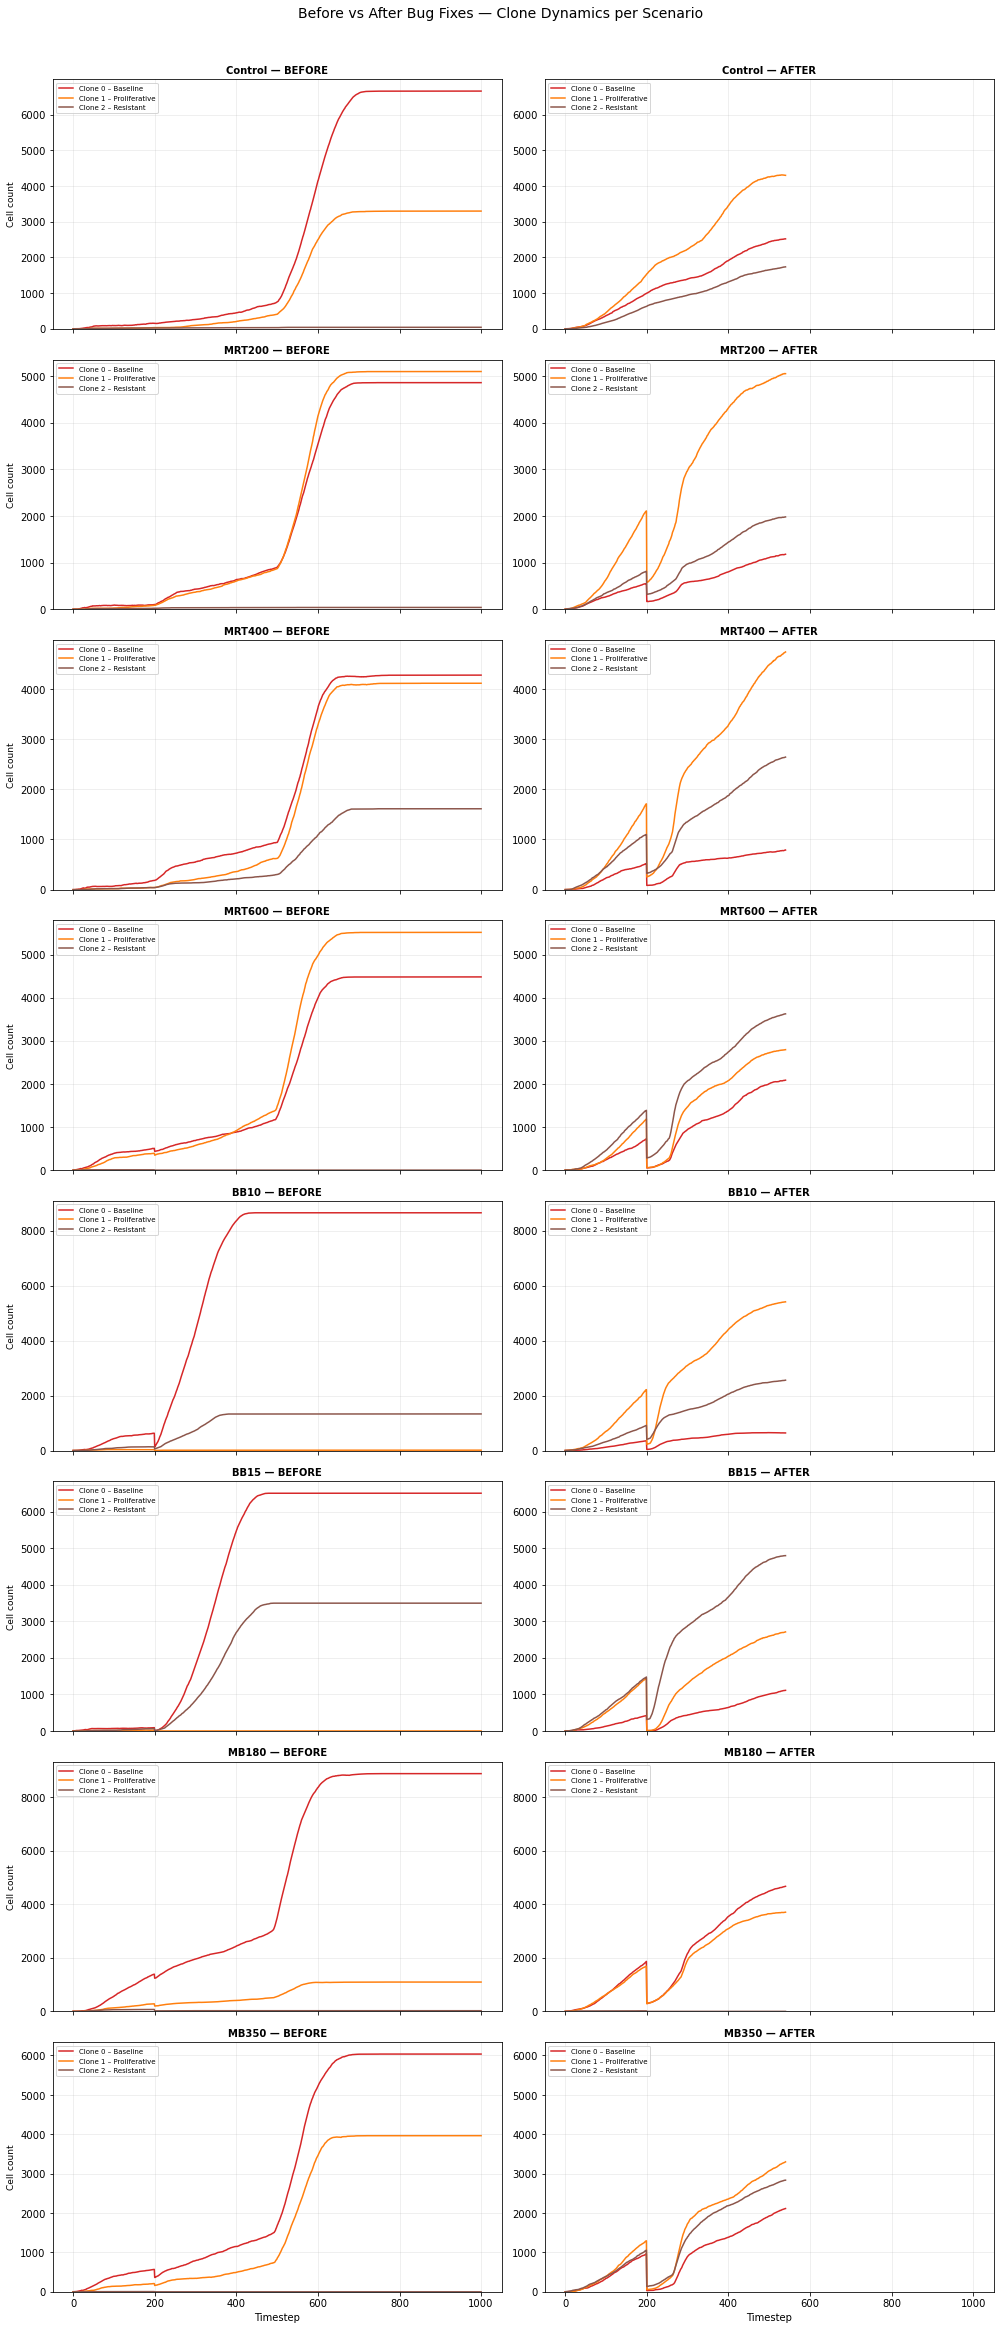

Saved to HALModeling2024Outs/before_after_clones.png


In [13]:
# --- Before vs After: clone dynamics per scenario ---
# Each row = one scenario. Left column = old code, right column = new code.
# y-axes are matched within each row so you can compare clone counts directly.
CLONE_COLS_OLD = ["TumorClone0", "TumorClone1", "TumorClone2"]
CLONE_LABELS_SHORT = ["Clone 0 \u2013 Baseline", "Clone 1 \u2013 Proliferative", "Clone 2 \u2013 Resistant"]
CLONE_COLORS_BA = ["#d62728", "#ff7f0e", "#8c564b"]

def load_new_single_run(scenario, min_date="20260415"):
    """Load the most recent single trial for clean clone-level visualisation.
    Uses the latest file (sorted by filename = timestamp) to get the newest run."""
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not filtered:
        return None
    return pd.read_csv(filtered[-1])  # -1 = latest file

clone_scenarios = ["Control", "MRT200", "MRT400", "MRT600", "BB10", "BB15", "MB180", "MB350"]

n_scen = len(clone_scenarios)
# Create a tall figure: one row per scenario, two columns (before/after)
fig, axes = plt.subplots(n_scen, 2, figsize=(14, 4 * n_scen), sharex=True)

for row, scen in enumerate(clone_scenarios):
    ax_old = axes[row, 0]  # left = BEFORE
    ax_new = axes[row, 1]  # right = AFTER

    row_max = 0  # track max cell count across both panels for this row

    # --- Left: OLD clone dynamics (last available trial from Tanaya's data) ---
    if scen in old_data and old_data[scen]['trials']:
        df_old = old_data[scen]['trials'][-1]  # use last trial
        t_old = df_old["Timestep"]
        for col, label, color in zip(CLONE_COLS_OLD, CLONE_LABELS_SHORT, CLONE_COLORS_BA):
            if col in df_old.columns:
                ax_old.plot(t_old, df_old[col], color=color, linewidth=1.5, label=label)
                row_max = max(row_max, df_old[col].max())
        ax_old.set_title(f'{scen} \u2014 BEFORE', fontsize=10, fontweight='bold')
        ax_old.legend(fontsize=7, loc='upper left')
    else:
        ax_old.text(0.5, 0.5, 'No old data', ha='center', va='center', transform=ax_old.transAxes)
        ax_old.set_title(f'{scen} \u2014 BEFORE (no data)', fontsize=10)

    ax_old.set_ylabel('Cell count', fontsize=9)
    ax_old.grid(True, alpha=0.25)

    # --- Right: NEW clone dynamics (latest trial from current model) ---
    df_new = load_new_single_run(scen)
    if df_new is not None:
        t_new = df_new["Timestep"]
        for col, label, color in zip(CLONE_COLS_OLD, CLONE_LABELS_SHORT, CLONE_COLORS_BA):
            if col in df_new.columns:
                ax_new.plot(t_new, df_new[col], color=color, linewidth=1.5, label=label)
                row_max = max(row_max, df_new[col].max())
        ax_new.set_title(f'{scen} \u2014 AFTER', fontsize=10, fontweight='bold')
        ax_new.legend(fontsize=7, loc='upper left')
    else:
        ax_new.text(0.5, 0.5, 'No new data', ha='center', va='center', transform=ax_new.transAxes)
        ax_new.set_title(f'{scen} \u2014 AFTER (no data)', fontsize=10)

    ax_new.grid(True, alpha=0.25)

    # Force both panels in this row to the same y-axis
    if row_max > 0:
        ax_old.set_ylim(0, row_max * 1.05)
        ax_new.set_ylim(0, row_max * 1.05)

    # Only add x-axis labels on the bottom row to reduce clutter
    if row == n_scen - 1:
        ax_old.set_xlabel('Timestep', fontsize=10)
        ax_new.set_xlabel('Timestep', fontsize=10)

fig.suptitle('Before vs After Bug Fixes \u2014 Clone Dynamics per Scenario',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/before_after_clones.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/before_after_clones.png")

---

## Clonal Heterogeneity Analysis

Heterogeneity doesn't primarily change total tumour volume — it changes **tumour composition**.
After radiation, resistant subclones (Clone 2 – InvasiveResistant) survive better and come to
dominate the regrowing tumour. The plots below demonstrate this effect:

1. **Clone fraction over time** — how each clone's share of the tumour shifts after treatment
2. **Per-clone survival across treatment scenarios** — which clones survive which treatments
3. **Heterogeneity ON vs OFF** — total volume looks similar, but composition is dramatically different

### Clone fraction over time — Control vs Treatment scenarios

Each panel shows one scenario. The stacked area represents the fraction of the total
tumour made up by each clone. In Control, the composition stays roughly stable.
After radiation (vertical dashed line), Clone 2 (InvasiveResistant) should become
a larger fraction of the surviving tumour — this is the key heterogeneity effect.

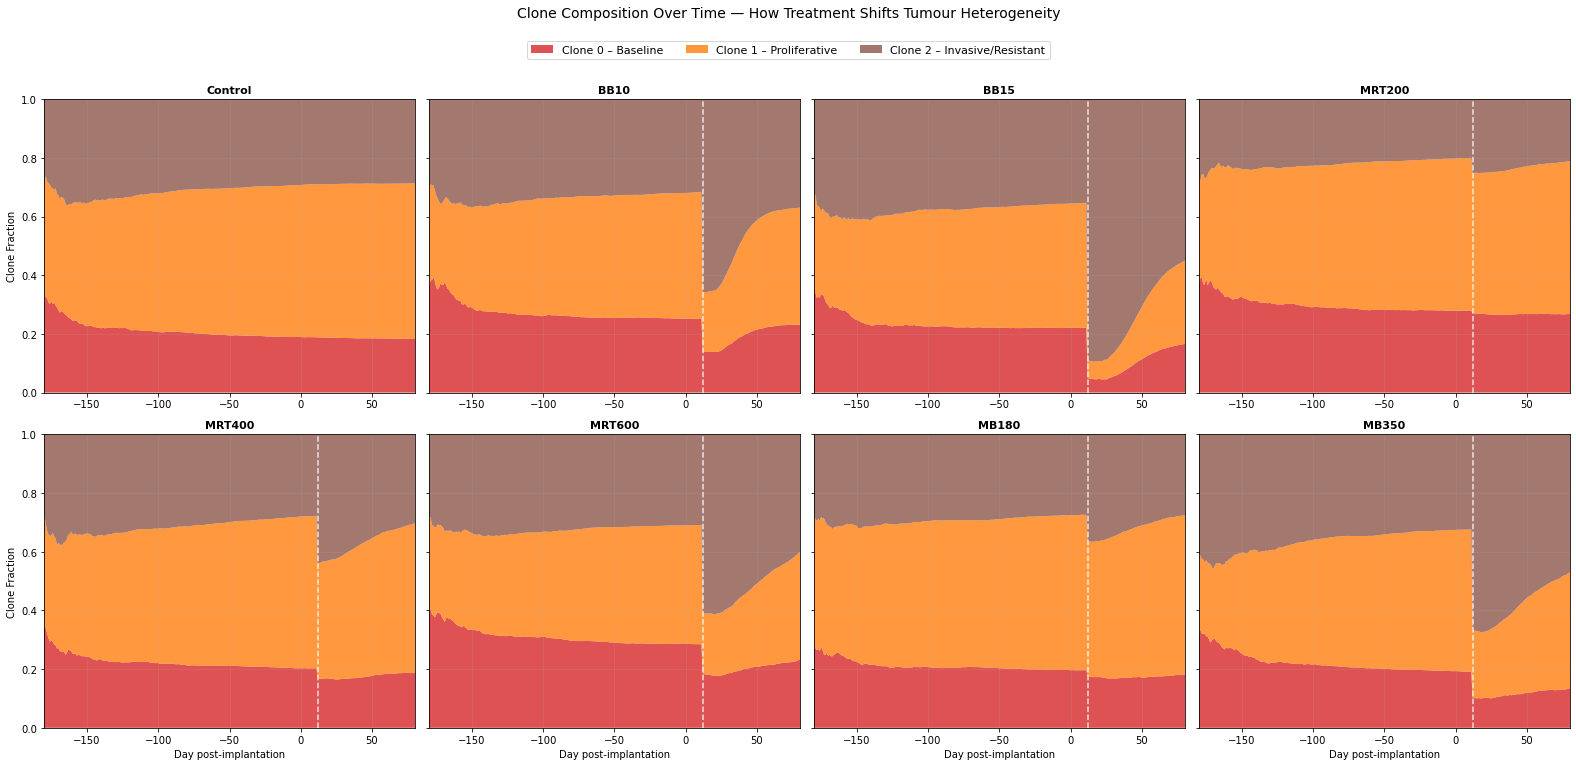

Saved to HALModeling2024Outs/clone_fraction_over_time.png


In [14]:
# --- Clone fraction over time: stacked area plots ---
# Shows how the PROPORTION of each clone changes over the simulation.
# In Control, Clone 1 (Proliferative) gradually dominates because it divides faster.
# After radiation, Clone 2 (Resistant) gains share — its low alpha means
# radiation kills fewer of its cells, so it survives better.
fraction_scenarios = ["Control", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

# 2x4 grid of stacked area plots, one per scenario
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()  # flatten so we can index with a single integer

for idx, scen in enumerate(fraction_scenarios):
    ax = axes[idx]

    # Load trial CSVs for this scenario (with date filter)
    folder = os.path.join(BASE_DIR, f"Scenario{scen}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= "20260415"]

    if not filtered:
        ax.set_title(f'{scen} (no data)', fontsize=10)
        continue

    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)

    # Average each clone's cell count across all 10 trials
    clone0 = np.mean([df['TumorClone0'].values[:min_len] for df in trials], axis=0)
    clone1 = np.mean([df['TumorClone1'].values[:min_len] for df in trials], axis=0)
    clone2 = np.mean([df['TumorClone2'].values[:min_len] for df in trials], axis=0)
    total = clone0 + clone1 + clone2

    # Convert counts to fractions (each clone / total tumour)
    # np.where avoids division by zero in early timesteps before the tumour seeds
    safe_total = np.where(total > 0, total, 1)
    frac0 = clone0 / safe_total
    frac1 = clone1 / safe_total
    frac2 = clone2 / safe_total

    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)

    # stackplot draws coloured bands stacked on top of each other (sums to 1.0)
    ax.stackplot(days, frac0, frac1, frac2,
                 labels=CLONE_LABELS if idx == 0 else [None]*3,  # legend only on first panel
                 colors=CLONE_COLORS, alpha=0.8)

    # White dashed line marks radiation day (not shown for Control — no radiation)
    if scen != "Control":
        ax.axvline(x=RADIATION_DAY, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

    ax.set_title(scen, fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 80)
    ax.set_ylim(0, 1)        # fractions always between 0 and 1
    if idx % 4 == 0:         # only label y-axis on leftmost panels
        ax.set_ylabel('Clone Fraction', fontsize=10)
    if idx >= 4:              # only label x-axis on bottom row
        ax.set_xlabel('Day post-implantation', fontsize=10)
    ax.grid(True, alpha=0.2)

# Single shared legend at the top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Clone Composition Over Time \u2014 How Treatment Shifts Tumour Heterogeneity',
             fontsize=14, y=1.06)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/clone_fraction_over_time.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/clone_fraction_over_time.png")

### Per-clone counts across treatment scenarios (mean of 10 trials)

Each panel shows how the three clone populations change over time for a given treatment.
Unlike the stacked fraction plot above, this shows **absolute cell counts** so you can
see both the total tumour size and which clone dominates regrowth.

Key finding: after high-dose radiation (MRT400, MRT600, MB350), Clone 2 (InvasiveResistant)
makes up a disproportionately large share of the surviving cells, even though it started
from just 1 seed cell — the same as the other clones.

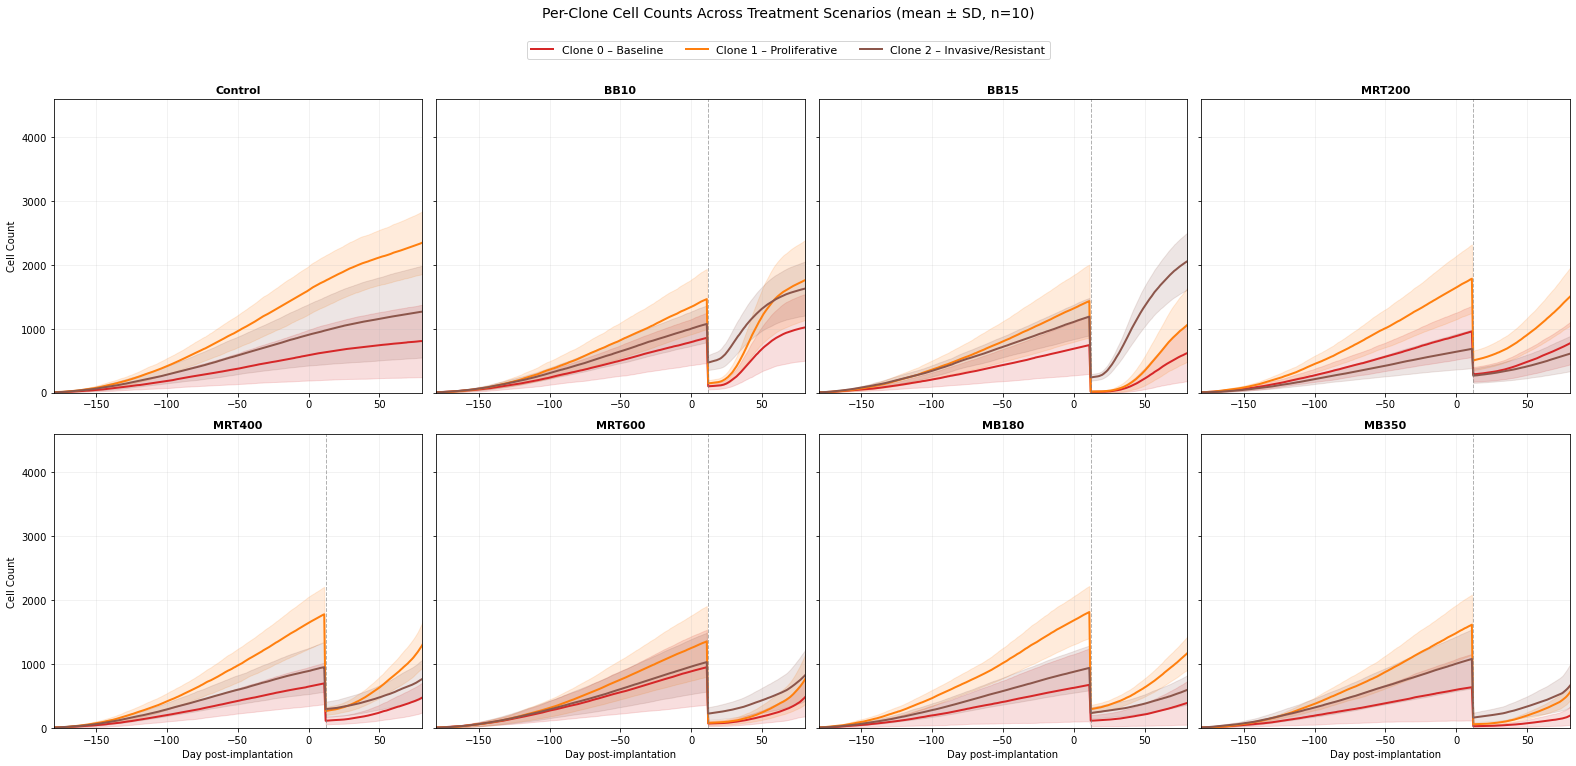

Saved to HALModeling2024Outs/clone_counts_across_scenarios.png


In [15]:
# --- Per-clone absolute counts across scenarios ---
# Unlike the fraction plot above, this shows RAW CELL COUNTS so we can
# see both tumour size AND composition at the same time.
# All panels share the same y-axis (sharey=True + explicit ylim) so that
# the dramatic cell kill in high-dose MRT/MB scenarios is visually obvious.
count_scenarios = ["Control", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

# --- First pass: find the global maximum cell count across all scenarios ---
# We need this before plotting so all panels can use the same y-axis range.
global_ymax = 0
for scen in count_scenarios:
    folder = os.path.join(BASE_DIR, f"Scenario{scen}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= "20260415"]
    if not filtered:
        continue
    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)
    for col in CLONE_COLS:
        # Compute the mean across trials and find its peak
        matrix = np.stack([df[col].values[:min_len] for df in trials])
        peak = matrix.mean(axis=0).max()
        if peak > global_ymax:
            global_ymax = peak

# --- Second pass: create the plots with the shared y-axis ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for idx, scen in enumerate(count_scenarios):
    ax = axes[idx]

    # Load and filter trial CSVs
    folder = os.path.join(BASE_DIR, f"Scenario{scen}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= "20260415"]

    if not filtered:
        ax.set_title(f'{scen} (no data)', fontsize=10)
        continue

    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)  # convert to biological days

    # Plot each clone as a line (mean) with a shaded SD band
    for col, label, color in zip(CLONE_COLS, CLONE_LABELS, CLONE_COLORS):
        matrix = np.stack([df[col].values[:min_len] for df in trials])  # (n_trials, n_timesteps)
        mean = matrix.mean(axis=0)
        std = matrix.std(axis=0)
        ax.plot(days, mean, color=color, linewidth=2, label=label if idx == 0 else None)
        ax.fill_between(days, mean - std, mean + std, color=color, alpha=0.15)  # shaded SD band

    # Grey dashed line marks the day radiation was applied
    if scen != "Control":
        ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(scen, fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 80)
    # Set explicit y-limit from the global max so all panels use the same scale
    ax.set_ylim(0, global_ymax * 1.05)
    if idx % 4 == 0:
        ax.set_ylabel('Cell Count', fontsize=10)
    if idx >= 4:
        ax.set_xlabel('Day post-implantation', fontsize=10)
    ax.grid(True, alpha=0.2)

# Create a manual legend (Line2D objects) for the top of the figure
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in CLONE_COLORS]
fig.legend(handles, CLONE_LABELS, loc='upper center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Per-Clone Cell Counts Across Treatment Scenarios (mean \u00b1 SD, n=10)',
             fontsize=14, y=1.06)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/clone_counts_across_scenarios.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/clone_counts_across_scenarios.png")

### Heterogeneity ON vs OFF — Tumour Volume Comparison

Side-by-side comparison using `HALModeling2024Outs` (heterogeneity ON, 3 distinct clones)
and `HALModeling2024Outs_NoHet` (heterogeneity OFF, all multipliers = 1.0).

**Expected result:** The total volume curves should look similar — this is correct.
Heterogeneity doesn't primarily change total tumour size. The real difference is in
the **clone composition**, shown in the next plot.

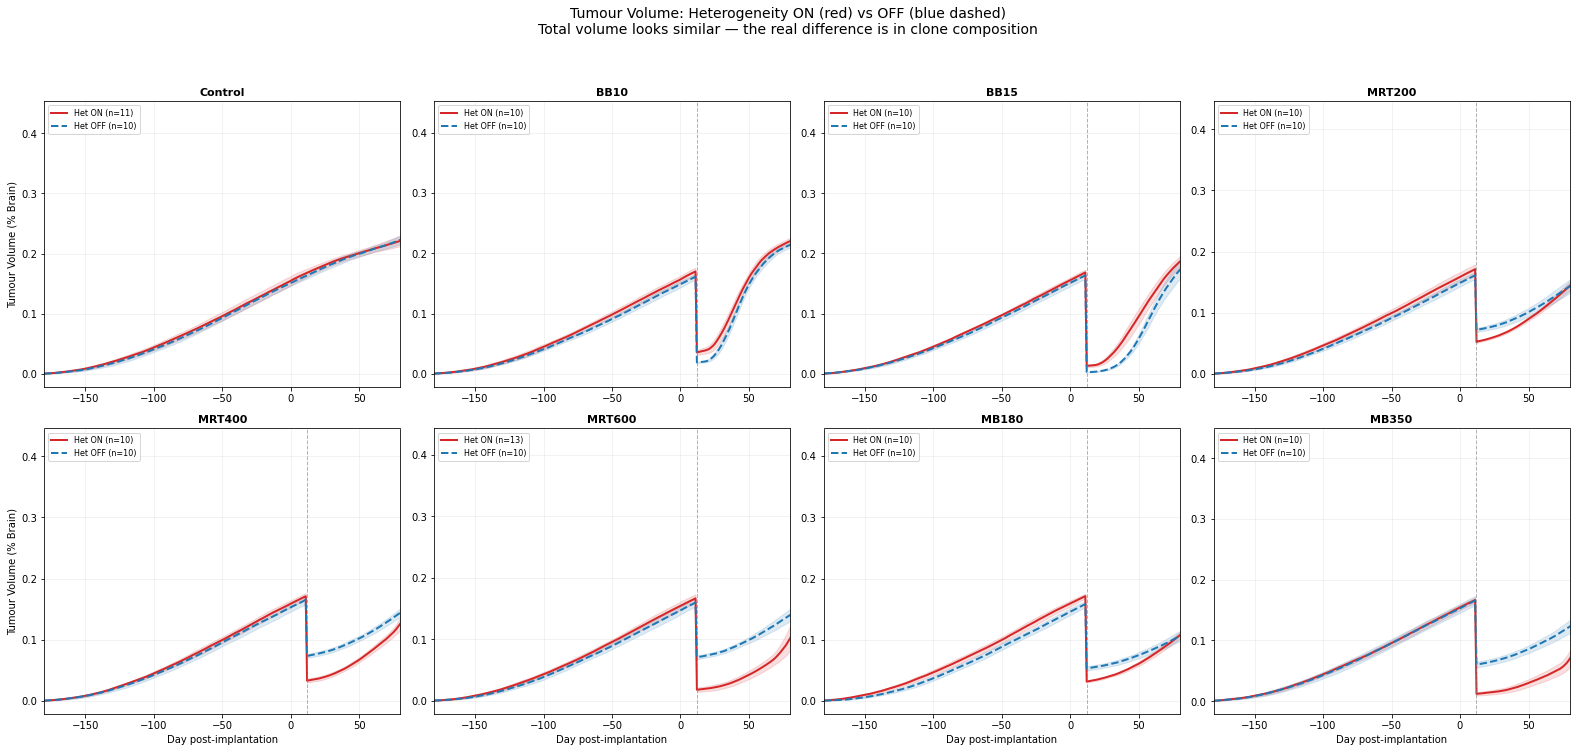

Saved to HALModeling2024Outs/het_vs_nohet_volume.png


In [16]:
# --- Heterogeneity ON vs OFF: tumour volume comparison ---
# Compares the full model (3 subclones with different biological properties)
# against a homogeneous tumour (all cells identical — like Tanaya's original).
# The key finding: total tumour VOLUME looks similar in both cases, but the
# underlying clone COMPOSITION is very different (shown in the next cell).
NOHET_DIR = "HALModeling2024Outs_NoHet"  # output folder from the homogeneous model

def load_scenario_volume(base_dir, scenario, min_date="20260415"):
    """Load mean tumour volume for a scenario from any output directory."""
    folder = os.path.join(base_dir, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not filtered:
        return None
    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])
    all_volumes = cell_count_to_volume_pct(all_counts)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    return {'days': days, 'mean': all_volumes.mean(axis=0), 'std': all_volumes.std(axis=0),
            'n_trials': len(trials)}

het_vs_nohet_scenarios = ["Control", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, scen in enumerate(het_vs_nohet_scenarios):
    ax = axes[idx]

    # Load data from both model variants
    het_data = load_scenario_volume(BASE_DIR, scen)       # heterogeneous (3 clones)
    nohet_data = load_scenario_volume(NOHET_DIR, scen)    # homogeneous (1 clone type)

    # Red solid line = heterogeneous model (3 clones with different properties)
    if het_data is not None:
        mask = het_data['days'] >= -180
        ax.plot(het_data['days'][mask], het_data['mean'][mask],
                color='#d62728', linewidth=2, label=f'Het ON (n={het_data["n_trials"]})')
        # Shaded band = +/- 1 SD across trials
        ax.fill_between(het_data['days'][mask],
                        het_data['mean'][mask] - het_data['std'][mask],
                        het_data['mean'][mask] + het_data['std'][mask],
                        color='#d62728', alpha=0.15)

    # Blue dashed line = homogeneous model (all cells identical)
    if nohet_data is not None:
        mask = nohet_data['days'] >= -180
        ax.plot(nohet_data['days'][mask], nohet_data['mean'][mask],
                color='#1f77b4', linewidth=2, linestyle='--',
                label=f'Het OFF (n={nohet_data["n_trials"]})')
        ax.fill_between(nohet_data['days'][mask],
                        nohet_data['mean'][mask] - nohet_data['std'][mask],
                        nohet_data['mean'][mask] + nohet_data['std'][mask],
                        color='#1f77b4', alpha=0.15)

    if scen != "Control":
        ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(scen, fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 80)
    ax.legend(fontsize=8, loc='upper left')
    if idx % 4 == 0:
        ax.set_ylabel('Tumour Volume (% Brain)', fontsize=10)
    if idx >= 4:
        ax.set_xlabel('Day post-implantation', fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle('Tumour Volume: Heterogeneity ON (red) vs OFF (blue dashed)\n'
             'Total volume looks similar \u2014 the real difference is in clone composition',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/het_vs_nohet_volume.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/het_vs_nohet_volume.png")

### Heterogeneity ON vs OFF — Clone Composition After Radiation

This is the key comparison. Both models have 3 clones, but:
- **Het OFF:** all multipliers = 1.0, so clones behave identically → composition stays ~33/33/33%
- **Het ON:** Clone 2 is radioresistant + immune-evasive → it dominates after treatment

Left bars = Het OFF (equal fractions). Right bars = Het ON (shifted toward Clone 2).
The stronger the radiation, the bigger the shift.

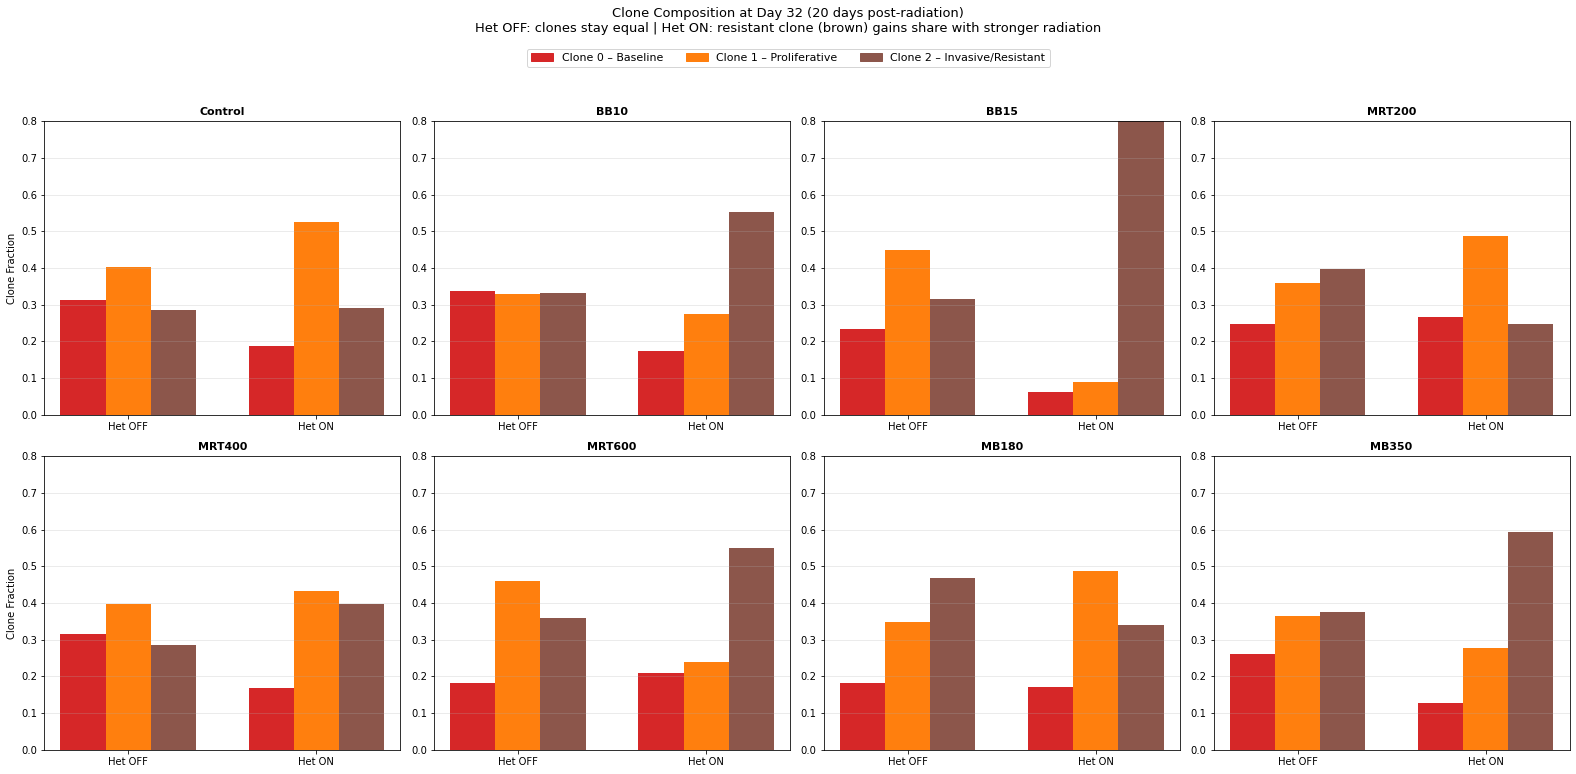

Saved to HALModeling2024Outs/het_vs_nohet_clone_composition.png


In [17]:
# --- Het ON vs OFF: clone composition snapshot after radiation ---
# Compares clone fractions at a fixed post-radiation timepoint (Day 32).
# With het OFF: all three "clones" stay at ~33% each (no biological differences).
# With het ON: Clone 2 (Resistant) gains share under stronger radiation
# because its low alpha (0.4x) means fewer cells are killed by the LQ model.
POST_TIMESTEP_COMP = 220  # timestep 220 = Day 32 = 20 days after radiation

comp_scenarios = ["Control", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

def get_clone_fractions_at_timestep(base_dir, scenario, timestep, min_date="20260415"):
    """Get mean clone fractions at a specific timestep across all trials.
    Returns a 3-element array [frac_clone0, frac_clone1, frac_clone2]."""
    folder = os.path.join(base_dir, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not filtered:
        return None
    fracs = []
    for f in filtered:
        df = pd.read_csv(f)
        if timestep < len(df):
            row = df.iloc[timestep]  # get the row at the target timestep
            c0, c1, c2 = row['TumorClone0'], row['TumorClone1'], row['TumorClone2']
            total = c0 + c1 + c2
            if total > 0:
                fracs.append([c0/total, c1/total, c2/total])  # convert to fractions
    if fracs:
        return np.mean(fracs, axis=0)  # average across trials
    return None

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

bar_width = 0.12
# Offset each clone's bar slightly so all 3 fit side-by-side
clone_offsets = [-bar_width, 0, bar_width]

for idx, scen in enumerate(comp_scenarios):
    ax = axes[idx]

    # Get fractions from both model variants at the same timestep
    het_fracs = get_clone_fractions_at_timestep(BASE_DIR, scen, POST_TIMESTEP_COMP)
    nohet_fracs = get_clone_fractions_at_timestep(NOHET_DIR, scen, POST_TIMESTEP_COMP)

    x_positions = [0, 0.5]  # Het OFF on left, Het ON on right
    labels_x = ['Het OFF', 'Het ON']

    # Draw 3 bars (one per clone) at each x position
    for ci, (label, color) in enumerate(zip(CLONE_LABELS, CLONE_COLORS)):
        vals = []
        vals.append(nohet_fracs[ci] if nohet_fracs is not None else 0)
        vals.append(het_fracs[ci] if het_fracs is not None else 0)

        ax.bar([x + clone_offsets[ci] for x in x_positions], vals,
               bar_width, color=color, label=label if idx == 0 else None)

    ax.set_title(scen, fontsize=11, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels_x, fontsize=10)
    ax.set_ylim(0, 0.8)
    if idx % 4 == 0:
        ax.set_ylabel('Clone Fraction', fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

# Shared legend using coloured rectangles
handles = [plt.Rectangle((0,0), 1, 1, color=c) for c in CLONE_COLORS]
fig.legend(handles, CLONE_LABELS, loc='upper center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f'Clone Composition at Day {timestep_to_day(POST_TIMESTEP_COMP):.0f} (20 days post-radiation)\n'
             'Het OFF: clones stay equal | Het ON: resistant clone (brown) gains share with stronger radiation',
             fontsize=13, y=1.07)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/het_vs_nohet_clone_composition.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/het_vs_nohet_clone_composition.png")

---

## Tanaya's Baseline Model vs Current Model

Tanaya Bowade's original ABM (tagged `tanaya-baseline` in Git, verified against
`github.com/tanayab/ABM_GliobMul`) served as the starting point for this project.
The table below summarises every major change made to the model. Unlike the Het ON
vs OFF comparison above (which isolates a single variable), this comparison reflects
the **full scope of contributions** — multiple features were added simultaneously.

### Parameter and Feature Comparison

| Feature | Tanaya Baseline | Current Model | Rationale |
|---------|----------------|---------------|-----------|
| **Tumour clones** | 1 (uniform) | 3 subclones (Baseline, Proliferative, InvasiveResistant) | GBM tumours are genetically heterogeneous; clonal diversity drives treatment resistance and recurrence |
| **Growth multipliers** | N/A (single rate) | Clone 0: x1.0, Clone 1: x1.1, Clone 2: x0.95 | Proliferative clone grows faster; resistant clone trades growth for survival |
| **Radiosensitivity (alpha)** | N/A | Clone 0: x1.0, Clone 1: x1.1, Clone 2: x0.4 | InvasiveResistant clone has ~60% lower radiosensitivity, matching glioma stem cell literature |
| **Immune kill multiplier** | N/A | Clone 0: x1.0, Clone 1: x1.1, Clone 2: x0.3 | Resistant clone evades immune response (PD-L1 upregulation, low immunogenicity) |
| **Valley dose (MRT/MB)** | None — only peak beams irradiated | Valley dose applied to inter-beam cells via `valleyDoseRatio` | Physical MRT/MB beams produce valley regions between peaks; ignoring this overestimates spatial radiation effectiveness |
| **Valley-to-peak ratio** | N/A | MRT: 0.015, MB: 0.03 | Scaled for single-timestep LQ model; physical VPDR is ~5% (MRT) / ~10% (MB) |
| **MRT/MB immune suppression** | 1.1 (extreme escape) | 0.51 (same as BB/Control) | Tumour biology shouldn't change based on radiation type; only the radiation itself differs |
| **BB infiltration rate** | 0.1 (explicit per scenario) | 0.5 (FigParameters default) | Higher baseline infiltration matches immune surveillance in immunocompetent hosts |
| **SFRT threshold** | 0.8 (only dense tumour irradiated) | 0.01 (any tissue overlap) | Real synchrotron beams irradiate all tissue they pass through, not just dense tumour |
| **Control scenario figure** | Figure 2 (mouse baseline, growth=0.217, no radiation params) | Figure 3 (GBM-specific, calibrated alpha/beta) | All scenarios now use consistent GBM-specific radiobiology |
| **Post-radiation signal** | None | DAMPs/cytokine signal that decays over time, drives immune infiltration after APCs die | Captures the delayed immune response observed experimentally after radiation |
| **Sublethal radiation damage** | None | Persistent damage that accumulates and repairs over time | LQ model alone doesn't capture repair kinetics between fractions |
| **Probability clamping** | None (dieProbRad + dieProbImm + divProb could exceed 1.0) | Clamped to ≤ 1.0 | Probabilities > 1.0 are biologically meaningless and cause simulation artefacts |
| **Static state reset** | None (BatchRunner trials leaked state) | `resetStaticState()` clears all static fields between trials | Defensive fix: prevents cross-trial contamination in batch runs |
| **CSV output** | 16 columns | 32 columns (adds per-clone counts, per-clone probabilities) | Enables post-hoc analysis of clone dynamics |

In [18]:
# --- Parameter comparison table: Tanaya's baseline vs current model ---
# Rendered as a styled pandas DataFrame for clean notebook display.
# Useful for the dissertation methods/results comparison section.
comparison_data = {
    'Feature': [
        'Tumour clones',
        'Growth rate multipliers',
        'Alpha (radiosensitivity) multipliers',
        'Beta (radiosensitivity) multipliers',
        'Immune kill multipliers',
        'Valley dose (MRT)',
        'Valley dose (MB)',
        'MRT/MB immuneSuppressionEffect',
        'BB tumorInfiltrationRate',
        'SFRT thresholdPercentage',
        'Control scenario figure',
        'Post-radiation signal decay',
        'Sublethal damage + repair',
        'Probability clamping (die+div <= 1)',
        'Static state reset (BatchRunner)',
        'CSV columns',
    ],
    'Tanaya Baseline': [
        '1 (uniform)',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'None',
        'None',
        '1.1',
        '0.1',
        '0.8',
        'Figure 2',
        'No',
        'No',
        'No',
        'No',
        '16',
    ],
    'Current Model': [
        '3 (Baseline, Proliferative, InvasiveResistant)',
        '1.0 / 1.1 / 0.95',
        '1.0 / 1.1 / 0.4',
        '1.0 / 1.1 / 0.6',
        '1.0 / 1.1 / 0.3',
        'VPDR = 0.015',
        'VPDR = 0.03',
        '0.51',
        '0.5 (default)',
        '0.01',
        'Figure 3',
        'Yes (exponential decay)',
        'Yes (accumulate + repair)',
        'Yes (die+div <= 1)',
        'Yes',
        '32',
    ],
}

# Create the DataFrame and set 1-based index for readability
df_comparison = pd.DataFrame(comparison_data)
df_comparison.index = df_comparison.index + 1
df_comparison.index.name = '#'

# Apply CSS styling for left-aligned, clean table display
styled = df_comparison.style.set_properties(**{
    'text-align': 'left',
    'font-size': '11px',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
])

print("Parameter comparison: Tanaya Baseline vs Current Model")
print("=" * 80)
display(styled)

Parameter comparison: Tanaya Baseline vs Current Model


,Feature,Tanaya Baseline,Current Model
#,,,
1,Tumour clones,1 (uniform),"3 (Baseline, Proliferative, InvasiveResistant)"
2,Growth rate multipliers,N/A,1.0 / 1.1 / 0.95
3,Alpha (radiosensitivity) multipliers,N/A,1.0 / 1.1 / 0.4
4,Beta (radiosensitivity) multipliers,N/A,1.0 / 1.1 / 0.6
5,Immune kill multipliers,N/A,1.0 / 1.1 / 0.3
6,Valley dose (MRT),None,VPDR = 0.015
7,Valley dose (MB),None,VPDR = 0.03
8,MRT/MB immuneSuppressionEffect,1.1,0.51
9,BB tumorInfiltrationRate,0.1,0.5 (default)


### Tanaya Baseline vs Current — Tumour Volume Comparison

**Important:** This is a *confounded* comparison — multiple features changed simultaneously
(heterogeneity, valley dose, immune recalibration, etc.), so differences cannot be
attributed to any single change. Use the Het ON vs OFF comparison above for isolating
the effect of heterogeneity specifically.

To generate Tanaya baseline data, run Tanaya's original code from the `tanaya-baseline`
Git tag into a separate output folder (`HALModeling2024Outs_Tanaya`). If that folder
does not yet exist, this section will display instructions instead of plots.

  Tanaya Control: 9 trials
  Tanaya BB5: 10 trials
  Tanaya BB10: 10 trials
  Tanaya BB15: 10 trials
  Tanaya MRT200: 10 trials
  Tanaya MRT400: 10 trials
  Tanaya MRT600: 10 trials
  Tanaya MB180: 10 trials
  Tanaya MB350: 10 trials


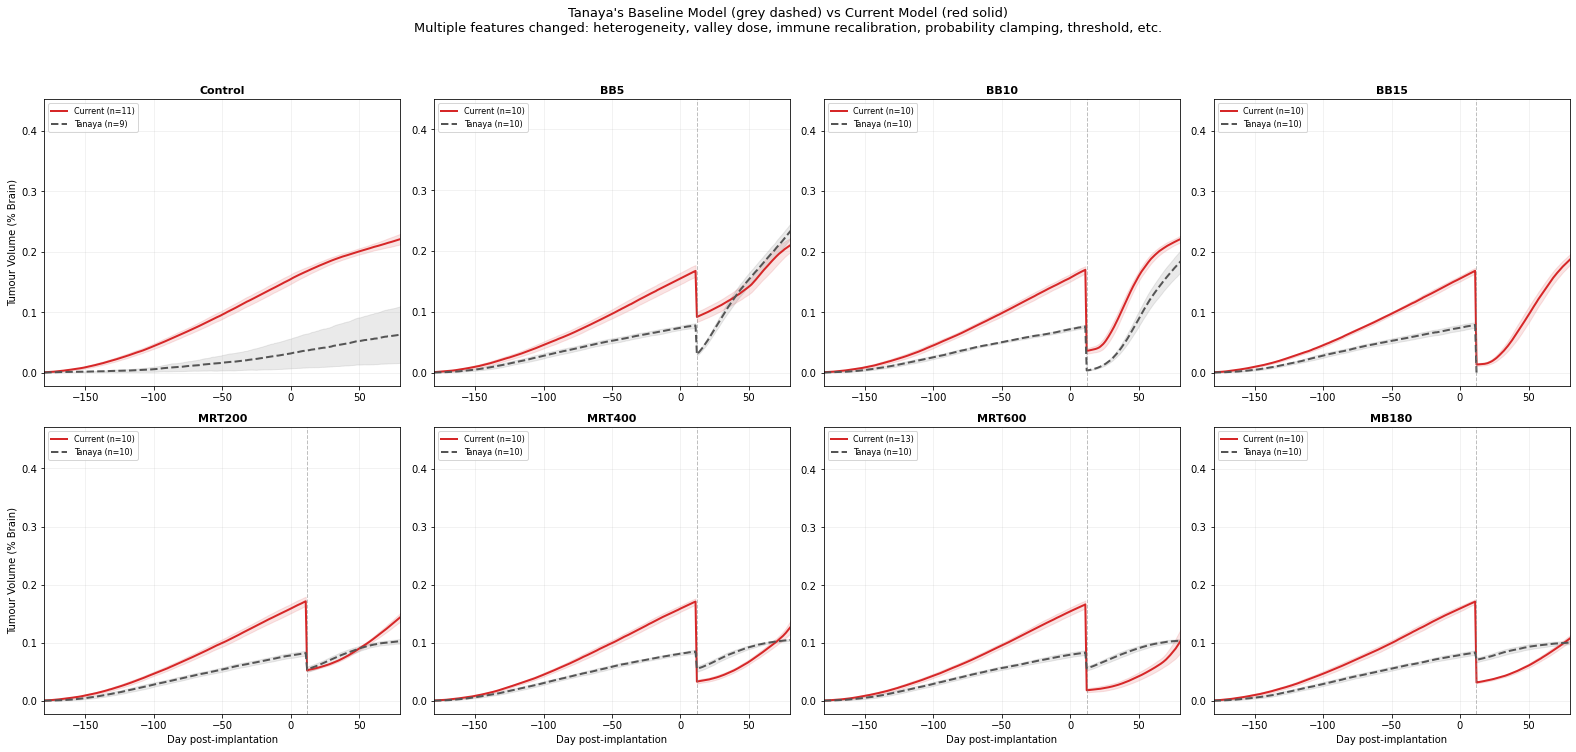

Saved to HALModeling2024Outs/tanaya_vs_current_volume.png


In [19]:
# --- Tanaya Baseline vs Current Model: tumour volume comparison ---
# This uses data generated by running Tanaya's unmodified code with BatchRunner,
# saved to HALModeling2024Outs_Tanaya/. If the folder doesn't exist yet,
# instructions for generating the data are printed at the bottom.
TANAYA_DIR = "HALModeling2024Outs_Tanaya"

tanaya_scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

def load_tanaya_volume(scenario):
    """Load Tanaya baseline CSV data. Her output has 16 columns (no per-clone data).
    No date filter needed — all files in this folder are from her unmodified code."""
    folder = os.path.join(TANAYA_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    if not csv_files:
        return None
    trials = [pd.read_csv(f) for f in csv_files]
    min_len = min(len(df) for df in trials)
    # Same volume conversion as our model — both use TumorCells column
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])
    all_volumes = cell_count_to_volume_pct(all_counts)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    return {
        'days': days,
        'mean': all_volumes.mean(axis=0),
        'std': all_volumes.std(axis=0),
        'n_trials': len(trials),
    }

# Only run this section if the Tanaya data folder exists
if os.path.isdir(TANAYA_DIR):
    # Load Tanaya's data for each scenario
    tanaya_data = {}
    for scen in tanaya_scenarios:
        result = load_tanaya_volume(scen)
        if result is not None:
            tanaya_data[scen] = result
            print(f"  Tanaya {scen}: {result['n_trials']} trials")
        else:
            print(f"  Tanaya {scen}: no data")

    if tanaya_data:
        # --- 2x4 subplot grid: one panel per scenario ---
        fig, axes = plt.subplots(2, 4, figsize=(22, 10))
        axes_flat = axes.flatten()

        # Only plot scenarios that have data in BOTH Tanaya and current folders
        plot_scenarios = [s for s in tanaya_scenarios if s in tanaya_data and s in scenario_data]

        for idx in range(8):
            ax = axes_flat[idx]
            if idx < len(plot_scenarios):
                scen = plot_scenarios[idx]

                # Current model: solid red line with shaded SD band
                d_new = scenario_data[scen]
                mask = d_new['days'] >= -180
                ax.plot(d_new['days'][mask], d_new['mean'][mask],
                        color='#d62728', linewidth=2,
                        label=f'Current (n={d_new["n_trials"]})')
                ax.fill_between(d_new['days'][mask],
                                d_new['mean'][mask] - d_new['std'][mask],
                                d_new['mean'][mask] + d_new['std'][mask],
                                color='#d62728', alpha=0.12)

                # Tanaya baseline: dashed grey line with shaded SD band
                d_old = tanaya_data[scen]
                mask_old = d_old['days'] >= -180
                ax.plot(d_old['days'][mask_old], d_old['mean'][mask_old],
                        color='#555555', linewidth=2, linestyle='--',
                        label=f'Tanaya (n={d_old["n_trials"]})')
                ax.fill_between(d_old['days'][mask_old],
                                d_old['mean'][mask_old] - d_old['std'][mask_old],
                                d_old['mean'][mask_old] + d_old['std'][mask_old],
                                color='#555555', alpha=0.12)

                # Mark radiation day for treated scenarios
                if scen != "Control":
                    ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--',
                               linewidth=1, alpha=0.5)

                ax.set_title(scen, fontsize=11, fontweight='bold')
                ax.legend(fontsize=8, loc='upper left')
                ax.set_xlim(-180, 80)
            else:
                ax.set_visible(False)  # hide unused panels

            if idx % 4 == 0:
                ax.set_ylabel('Tumour Volume (% Brain)', fontsize=10)
            if idx >= 4:
                ax.set_xlabel('Day post-implantation', fontsize=10)
            ax.grid(True, alpha=0.2)

        fig.suptitle(
            "Tanaya's Baseline Model (grey dashed) vs Current Model (red solid)\n"
            "Multiple features changed: heterogeneity, valley dose, immune recalibration, "
            "probability clamping, threshold, etc.",
             fontsize=13, y=1.04)
        plt.tight_layout()
        plt.savefig('HALModeling2024Outs/tanaya_vs_current_volume.png',
                     dpi=200, bbox_inches='tight')
        plt.show()
        print("Saved to HALModeling2024Outs/tanaya_vs_current_volume.png")
    else:
        print("No Tanaya data found in any scenario folders.")
else:
    print(f"'{TANAYA_DIR}' folder not found.")
    print()
    print("To generate Tanaya baseline data, follow these steps:")
    print("=" * 65)
    print("1. Open a terminal in the project root directory")
    print("2. Run:  git stash  (save your current work)")
    print("3. Run:  git checkout tanaya-baseline")
    print("4. In OnLattice2DCells/Main.java, change:")
    print('     public static final String directory = "HALModeling2024Outs";')
    print("   to:")
    print('     public static final String directory = "HALModeling2024Outs_Tanaya";')
    print("5. Compile and run BatchRunner (it will generate 10 trials x 9 scenarios)")
    print("6. Run:  git checkout feature-clonal-heterogeneity")
    print("7. Run:  git stash pop  (restore your work)")
    print("8. Re-run this notebook cell")
    print()
    print("Note: Tanaya's code does not have batchMode, so each trial will")
    print("open a GridWindow. The window closes automatically when the trial ends.")

### Tanaya vs Current — Immune Response and Lymphocyte Dynamics

Both CSV formats share the columns `Lymphocytes`, `ImmuneResponse`, and
`LymphocyteMigrationAttempted`. This comparison highlights how the recalibrated
immune parameters (infiltration rate, immune suppression) change the immune
dynamics, especially for MRT/MB scenarios where Tanaya used `immuneSuppressionEffect = 1.1`
(extreme immune escape) vs the current `0.51`.

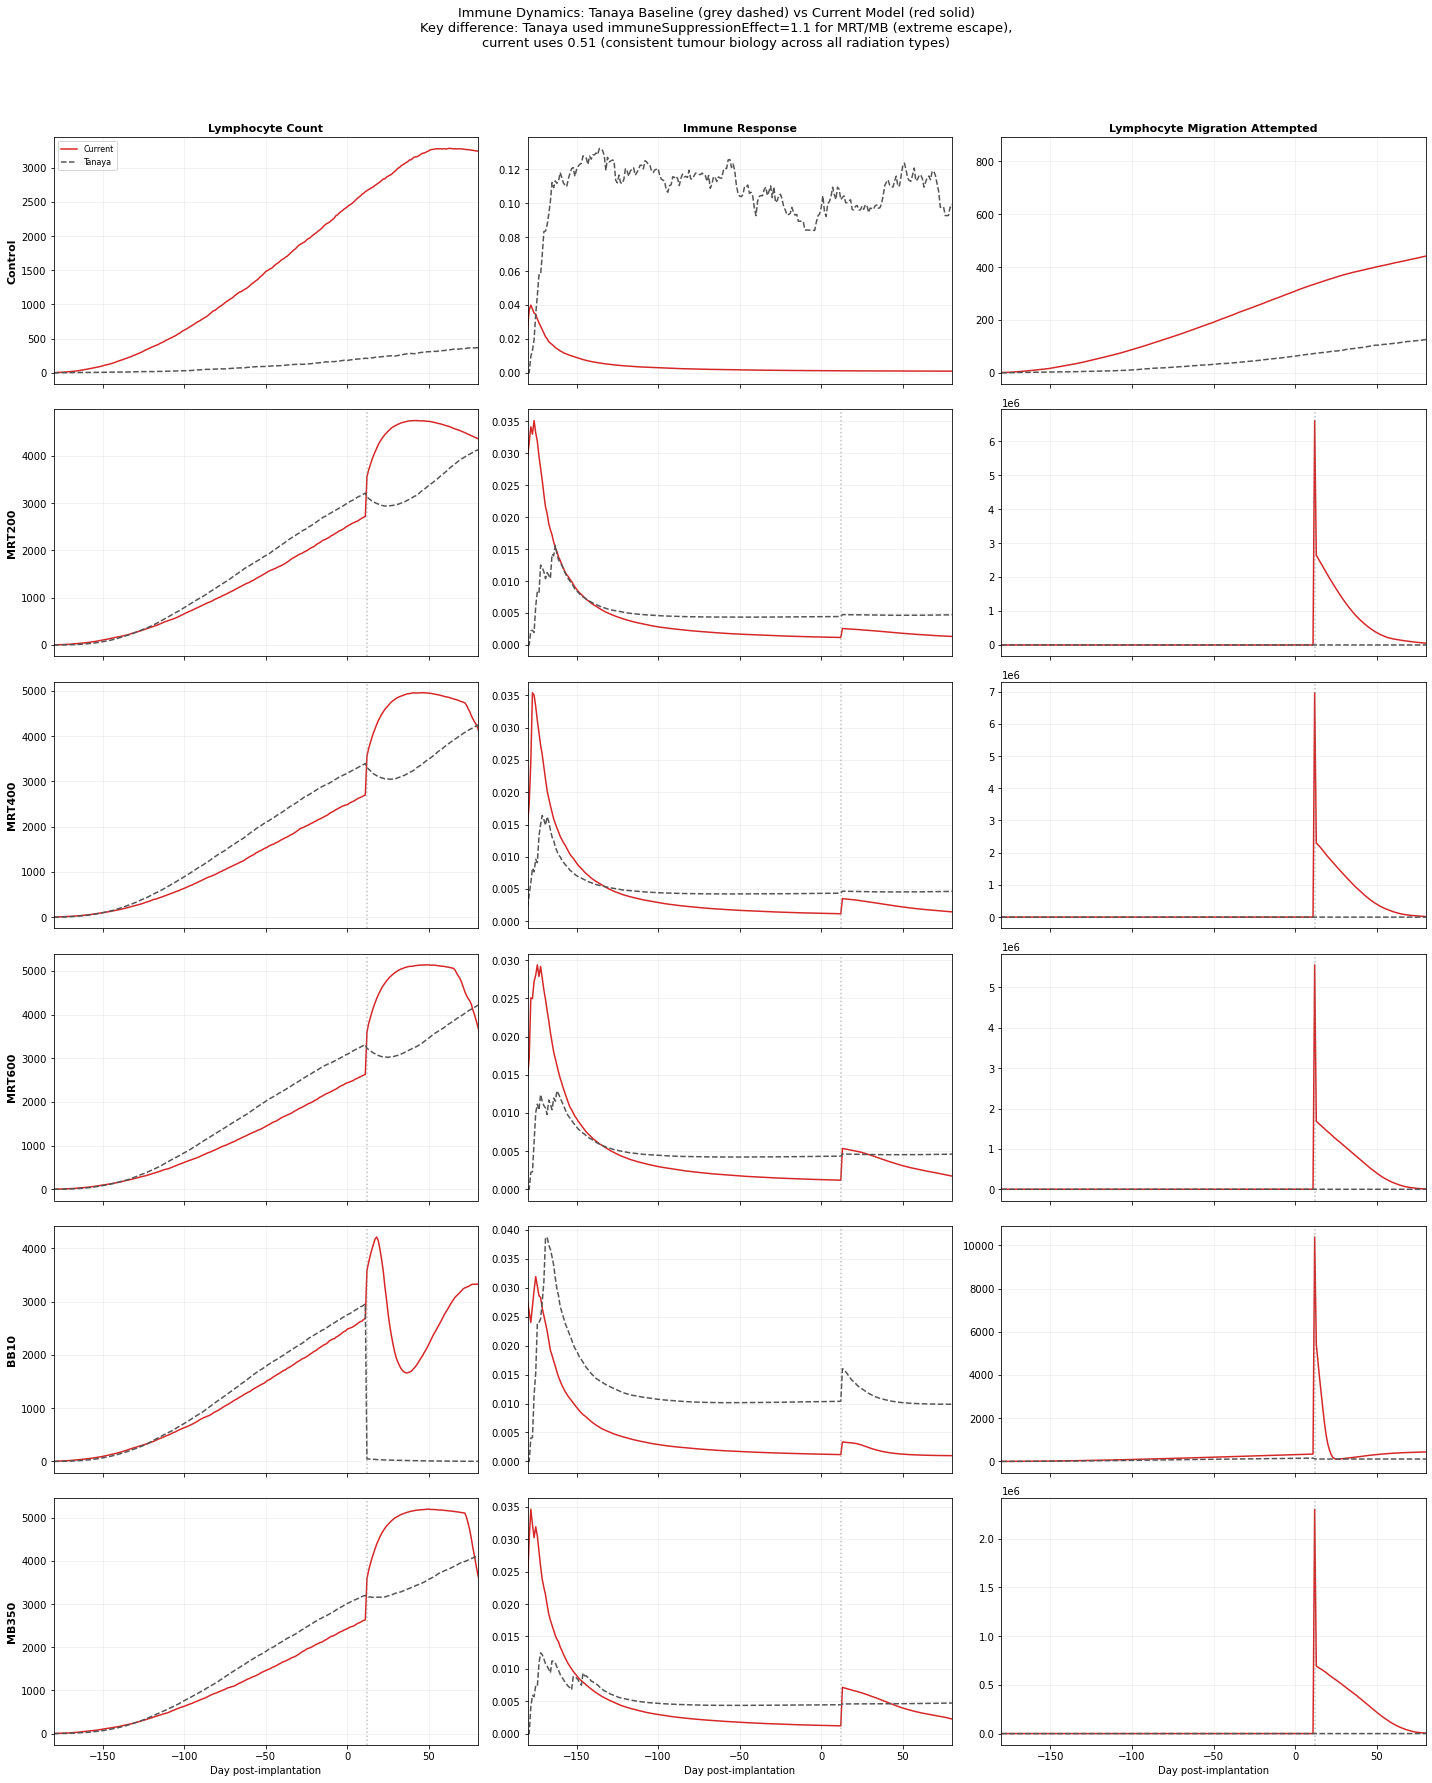

Saved to HALModeling2024Outs/tanaya_vs_current_immune.png


In [20]:
# --- Tanaya vs Current: immune dynamics comparison ---
# Three metrics per scenario (one column each):
#   1. Lymphocyte count — how many immune cells are present
#   2. Immune response signal — cumulative signal driving immune recruitment
#   3. Lymphocyte migration attempted — how many new lymphocytes tried to enter
# The key difference: Tanaya used immuneSuppressionEffect=1.1 for MRT/MB
# (extreme immune escape), while the current model uses 0.51 (consistent
# tumour biology across all radiation types).

def load_immune_data(base_dir, scenario, min_date=None):
    """Load mean immune metrics across trials from either Tanaya or current data."""
    folder = os.path.join(base_dir, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    if min_date:
        csv_files = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not csv_files:
        return None
    trials = [pd.read_csv(f) for f in csv_files]
    min_len = min(len(df) for df in trials)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)

    # Average each metric across all trials
    lymph = np.mean([df['Lymphocytes'].values[:min_len] for df in trials], axis=0)
    immune = np.mean([df['ImmuneResponse'].values[:min_len] for df in trials], axis=0)
    migration = np.mean([df['LymphocyteMigrationAttempted'].values[:min_len] for df in trials], axis=0)

    return {'days': days, 'lymphocytes': lymph, 'immune_response': immune,
            'migration': migration, 'n_trials': len(trials)}

if os.path.isdir(TANAYA_DIR):
    # Selected scenarios that best show immune dynamics differences
    immune_scenarios = ["Control", "MRT200", "MRT400", "MRT600", "BB10", "MB350"]

    # Grid: rows = scenarios, columns = metrics
    fig, axes = plt.subplots(len(immune_scenarios), 3, figsize=(20, 4 * len(immune_scenarios)),
                              sharex=True)

    col_titles = ['Lymphocyte Count', 'Immune Response', 'Lymphocyte Migration Attempted']

    for row, scen in enumerate(immune_scenarios):
        # Load data from both model versions
        d_new = load_immune_data(BASE_DIR, scen, min_date="20260415")
        d_old = load_immune_data(TANAYA_DIR, scen)  # no date filter for Tanaya data

        metrics = ['lymphocytes', 'immune_response', 'migration']

        for col, (metric, title) in enumerate(zip(metrics, col_titles)):
            ax = axes[row, col]

            # Current model: solid red line
            if d_new is not None:
                mask = d_new['days'] >= -180
                ax.plot(d_new['days'][mask], d_new[metric][mask],
                        color='#d62728', linewidth=1.5, label='Current')

            # Tanaya baseline: dashed grey line
            if d_old is not None:
                mask_old = d_old['days'] >= -180
                ax.plot(d_old['days'][mask_old], d_old[metric][mask_old],
                        color='#555555', linewidth=1.5, linestyle='--', label='Tanaya')

            # Dotted vertical line at radiation day
            if scen != "Control":
                ax.axvline(x=RADIATION_DAY, color='grey', linestyle=':', alpha=0.5)

            # Column titles on top row, row labels on left column
            if row == 0:
                ax.set_title(title, fontsize=11, fontweight='bold')
            if col == 0:
                ax.set_ylabel(scen, fontsize=11, fontweight='bold')
            if row == 0 and col == 0:
                ax.legend(fontsize=8)
            ax.grid(True, alpha=0.2)
            ax.set_xlim(-180, 80)

            if row == len(immune_scenarios) - 1:
                ax.set_xlabel('Day post-implantation', fontsize=10)

    fig.suptitle(
        "Immune Dynamics: Tanaya Baseline (grey dashed) vs Current Model (red solid)\n"
        "Key difference: Tanaya used immuneSuppressionEffect=1.1 for MRT/MB (extreme escape),\n"
        "current uses 0.51 (consistent tumour biology across all radiation types)",
        fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig('HALModeling2024Outs/tanaya_vs_current_immune.png',
                 dpi=200, bbox_inches='tight')
    plt.show()
    print("Saved to HALModeling2024Outs/tanaya_vs_current_immune.png")
else:
    print(f"Skipping immune dynamics comparison \u2014 '{TANAYA_DIR}' not found.")
    print("Generate Tanaya baseline data first (see instructions above).")

### Tanaya vs Current vs In Vivo — Normalised Growth Slope

Three-way comparison: Romano et al. (2021) in vivo data, Tanaya's baseline ABM,
and the current model. If the current model's slopes are closer to the in vivo
slopes than Tanaya's, this demonstrates that the model improvements moved the
simulation closer to experimental reality.

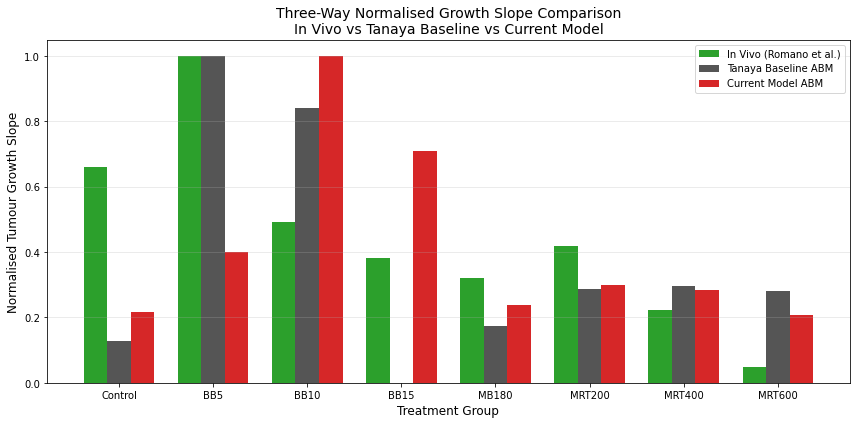


Treatment       In Vivo     Tanaya    Current
---------------------------------------------
Control           0.661      0.128      0.218
BB5               1.000      1.000      0.399
BB10              0.491      0.840      1.000
BB15              0.383      0.000      0.708
MB180             0.320      0.175      0.239
MRT200            0.419      0.287      0.300
MRT400            0.223      0.295      0.285
MRT600            0.049      0.279      0.206

Saved to HALModeling2024Outs/tanaya_vs_current_slopes.png


In [21]:
# --- Three-way normalised slope comparison: In Vivo vs Tanaya vs Current ---
# This is the most important VALIDATION plot in the notebook.
# It shows whether the RELATIVE RANKING of treatment effectiveness matches
# between real rats (in vivo) and both ABM versions.
# If the bar pattern is similar, the model captures the key biology.
if os.path.isdir(TANAYA_DIR):
    from scipy.stats import linregress

    slope_treatments = ["Control", "BB5", "BB10", "BB15", "MB180", "MRT200", "MRT400", "MRT600"]

    # In vivo data points (same as the slope comparison cell, repeated here
    # so this cell is self-contained and can be run independently)
    in_vivo_slopes_raw = {
        "Control": [(12, 2), (20, 12), (24, 18)],
        "BB5":     [(12, 2), (21, 20)],
        "BB10":    [(12, 2), (28, 15), (38, 28)],
        "BB15":    [(12, 2), (42, 25)],
        "MB180":   [(12, 2), (25, 10), (29, 13)],
        "MRT200":  [(12, 2), (21, 2), (26, 14), (29, 15)],
        "MRT400":  [(12, 2), (49, 68), (57, 40), (62, 0)],
        "MRT600":  [(12, 2), (54, 18), (62, 0)],
    }

    # Fit a linear regression to each in vivo dataset to get a growth slope
    iv_slopes = {}
    for t, pts in in_vivo_slopes_raw.items():
        x, y = zip(*pts)
        iv_slopes[t] = linregress(x, y).slope

    # Current model slopes: fit over the Day 12-60 post-radiation window
    current_slopes = {}
    for scen in slope_treatments:
        if scen in scenario_data:
            d = scenario_data[scen]
            mask = (d['days'] >= 12) & (d['days'] <= 60)
            current_slopes[scen] = linregress(d['days'][mask].astype(float), d['mean'][mask]).slope

    # Tanaya model slopes: same time window for fair comparison
    tanaya_slopes = {}
    for scen in slope_treatments:
        result = load_tanaya_volume(scen)
        if result is not None:
            mask = (result['days'] >= 12) & (result['days'] <= 60)
            if mask.sum() > 1:  # need at least 2 points for regression
                tanaya_slopes[scen] = linregress(
                    result['days'][mask].astype(float), result['mean'][mask]).slope

    # Normalise each dataset to its own maximum (makes bar heights comparable)
    def normalise_slopes(slopes_dict):
        max_val = max(slopes_dict.values()) if slopes_dict else 1
        return {k: v / max_val for k, v in slopes_dict.items()}

    iv_norm = normalise_slopes(iv_slopes)
    cur_norm = normalise_slopes(current_slopes)
    tan_norm = normalise_slopes(tanaya_slopes)

    # --- Grouped bar chart: 3 bars per treatment (in vivo, Tanaya, current) ---
    treatments_present = [t for t in slope_treatments
                          if t in iv_norm and (t in cur_norm or t in tan_norm)]
    x = np.arange(len(treatments_present))
    bar_w = 0.25  # width of each bar

    fig, ax = plt.subplots(figsize=(12, 6))

    # Green = in vivo, grey = Tanaya ABM, red = current ABM
    ax.bar(x - bar_w, [iv_norm.get(t, 0) for t in treatments_present],
           bar_w, label='In Vivo (Romano et al.)', color='#2ca02c')
    ax.bar(x,         [tan_norm.get(t, 0) for t in treatments_present],
           bar_w, label='Tanaya Baseline ABM', color='#555555')
    ax.bar(x + bar_w, [cur_norm.get(t, 0) for t in treatments_present],
           bar_w, label='Current Model ABM', color='#d62728')

    ax.set_xlabel('Treatment Group', fontsize=12)
    ax.set_ylabel('Normalised Tumour Growth Slope', fontsize=12)
    ax.set_title('Three-Way Normalised Growth Slope Comparison\n'
                 'In Vivo vs Tanaya Baseline vs Current Model',
                 fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(treatments_present, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('HALModeling2024Outs/tanaya_vs_current_slopes.png',
                 dpi=200, bbox_inches='tight')
    plt.show()

    # Print a numerical comparison table
    print(f"\n{'Treatment':<12} {'In Vivo':>10} {'Tanaya':>10} {'Current':>10}")
    print("-" * 45)
    for t in treatments_present:
        print(f"{t:<12} {iv_norm.get(t, 0):>10.3f} {tan_norm.get(t, 0):>10.3f} {cur_norm.get(t, 0):>10.3f}")

    print("\nSaved to HALModeling2024Outs/tanaya_vs_current_slopes.png")
else:
    print(f"Skipping slope comparison \u2014 '{TANAYA_DIR}' not found.")
    print("Generate Tanaya baseline data first (see instructions above).")